# **Supporting technical validation — aggression index appendix**

This is reference material, not meant to be read start-to-end: the full computation pipeline behind `raw_aggression_index`, plus the detailed validation and robustness work behind the headline results presented in `territorial_behavior_in_football.ipynb`. Each section is self-contained and linked to from the main narrative where relevant — the pressing-efficiency investigation, a full match-to-match variance and outlier analysis, per-pitch visualizations of recovery attempts, a match-state robustness check, and additional statistical depth (a mixture-model test of whether the Bourgeois-direction effect is one homogeneous population or several distinct clusters).

Covers the 2015/16 season across the Premier League, La Liga, Serie A, and Ligue 1 (Bundesliga excluded — StatsBomb's open-data release for that competition only covers one club's matches, not the full round-robin).

Section 2 (adjusting the score for match state, manager identity, dead rubbers, or quality mismatch) remains a placeholder — only the match-state check has been carried out so far, further down.

In [1]:
from statsbombpy import sb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
from statsbombpy.api_client import NoAuthWarning

warnings.filterwarnings("ignore", category=NoAuthWarning)

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

pd.set_option("display.max_columns", None)

# Plot style: real LaTeX when available (best-looking, e.g. local machines with a LaTeX
# install), a LaTeX-free fallback otherwise (Binder/Colab, which don't have LaTeX)
import shutil
import scienceplots

if shutil.which('latex'):
    plt.style.use(['science', 'nature'])
else:
    plt.style.use(['science', 'no-latex', 'nature'])
    plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['figure.figsize'] = [5, (4.8/6.4)*5]
plt.rcParams['figure.dpi'] = 150

# Nature style pins these to 7pt by default; bump for legibility
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9


# Raw aggression index (no control variables)

Bundesliga is excluded here since StatsBomb's open-data release for that competition only covers one team's (Bayer Leverkusen) matches, not the full round-robin.

In [2]:
BIG4_2015_16 = {
    "La Liga": (11, 27),
    "Ligue 1": (7, 27),
    "Premier League": (2, 27),
    "Serie A": (12, 27),
}

# Forward press rate

Forward press rate is the number of defensive-action **attempts** — pressures, tackles (`duel_type == "Tackle"` only, excluding aerial duels), interceptions, and fouls committed — a team makes while the ball is in the opponent's own half (`x > 60` in the team's own normalized frame), per opponent possession. It counts attempts regardless of outcome, since whether a tackle succeeds reflects player skill rather than team strategy, and it's zone-restricted by construction: a team that only engages once the ball reaches its own third scores near zero here, no matter how efficient it is once the ball arrives deep. No cross-team mirroring is needed — these are the team's own events, already in the team's own coordinate frame.

In [3]:
DEFENSIVE_ACTION_TYPES = ["Pressure", "Interception", "Foul Committed"]


def _loc_x(events):
    return events["location"].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)


def _is_tackle(events):
    return (events["type"] == "Duel") & (events["duel_type"] == "Tackle")


def _is_defensive_action_attempt(events):
    return events["type"].isin(DEFENSIVE_ACTION_TYPES) | _is_tackle(events)


def compute_forward_press_rate(events, team, opponent):
    loc_x = _loc_x(events)
    attempts_mask = (
        (events["team"] == team)
        & _is_defensive_action_attempt(events)
        & loc_x.notna()
        & (loc_x > 60)
    )
    num_attempts = attempts_mask.sum()
    opponent_possessions = events.loc[events["possession_team"] == opponent, "possession"].nunique()
    if opponent_possessions == 0:
        return np.nan
    return num_attempts / opponent_possessions

# Compute the raw aggression index for a sample of matches

Demonstrated here on the first 100 Premier League matches (200 team-match rows) to keep the notebook's runtime bounded. The same loop generalizes to every league in BIG4_2015_16 and every match_id once we're ready to run the full dataset.

In [4]:
def compute_aggression_index_for_match(match_id, home_team, away_team):
    events = sb.events(match_id=match_id)
    rows = []
    for team, opponent, venue in [(home_team, away_team, "Home"), (away_team, home_team, "Away")]:
        rows.append({
            "match_id": match_id,
            "team": team,
            "opponent": opponent,
            "venue": venue,
            "raw_aggression_index": compute_forward_press_rate(events, team, opponent),
        })
    return rows

In [5]:
competition_id, season_id = BIG4_2015_16["Premier League"]
matches = sb.matches(competition_id=competition_id, season_id=season_id)

sample_matches = matches.head(50)

raw_rows = []
for _, m in sample_matches.iterrows():
    raw_rows.extend(compute_aggression_index_for_match(m["match_id"], m["home_team"], m["away_team"]))

raw_scored_df = pd.DataFrame(raw_rows)
raw_scored_df.head(10)

,match_id,team,opponent,venue,raw_aggression_index
0,3754217,Chelsea,Arsenal,Home,1.034483
1,3754217,Arsenal,Chelsea,Away,0.610390
2,3754117,Aston Villa,Arsenal,Home,0.630952
3,3754117,Arsenal,Aston Villa,Away,0.807229
4,3754296,Arsenal,Manchester City,Home,0.689655
5,3754296,Manchester City,Arsenal,Away,0.822917
6,3753983,Swansea City,Arsenal,Home,0.922078
7,3753983,Arsenal,Swansea City,Away,0.986111
8,3754160,Arsenal,Sunderland,Home,0.560976
9,3754160,Sunderland,Arsenal,Away,0.626374


In [6]:
raw_scored_df.groupby("team")["raw_aggression_index"].mean().sort_values(ascending=False)

team
Manchester United       0.977163
Norwich City            0.954719
Everton                 0.950579
Watford                 0.916646
Liverpool               0.903687
Tottenham Hotspur       0.891156
Southampton             0.884634
Crystal Palace          0.866840
AFC Bournemouth         0.854438
Chelsea                 0.848999
Manchester City         0.843929
Newcastle United        0.825864
Leicester City          0.821209
Arsenal                 0.745364
Swansea City            0.728935
West Bromwich Albion    0.726621
Sunderland              0.715484
Aston Villa             0.656928
Stoke City              0.533444
West Ham United         0.461611
Name: raw_aggression_index, dtype: float64

# Forward press rate without fouls

Bournemouth topping the ranking above is a bit surprising given 2015/16 priors (Liverpool/Tottenham are the commonly cited pressing sides). One thing to rule out: whether `Foul Committed` events, rather than genuine pressing actions (pressures, tackles, interceptions), are driving that result. Recomputed here with fouls excluded from the attempt count.

In [7]:
DEFENSIVE_ACTION_TYPES_NO_FOULS = ["Pressure", "Interception"]


def _is_defensive_action_attempt_no_fouls(events):
    return events["type"].isin(DEFENSIVE_ACTION_TYPES_NO_FOULS) | _is_tackle(events)


def compute_forward_press_rate_no_fouls(events, team, opponent):
    loc_x = _loc_x(events)
    attempts_mask = (
        (events["team"] == team)
        & _is_defensive_action_attempt_no_fouls(events)
        & loc_x.notna()
        & (loc_x > 60)
    )
    num_attempts = attempts_mask.sum()
    opponent_possessions = events.loc[events["possession_team"] == opponent, "possession"].nunique()
    if opponent_possessions == 0:
        return np.nan
    return num_attempts / opponent_possessions

In [8]:
def compute_aggression_index_for_match_no_fouls(match_id, home_team, away_team):
    events = sb.events(match_id=match_id)
    rows = []
    for team, opponent, venue in [(home_team, away_team, "Home"), (away_team, home_team, "Away")]:
        rows.append({
            "match_id": match_id,
            "team": team,
            "opponent": opponent,
            "venue": venue,
            "raw_aggression_index_no_fouls": compute_forward_press_rate_no_fouls(events, team, opponent),
        })
    return rows

In [9]:
raw_rows_no_fouls = []
for _, m in sample_matches.iterrows():
    raw_rows_no_fouls.extend(
        compute_aggression_index_for_match_no_fouls(m["match_id"], m["home_team"], m["away_team"])
    )

raw_scored_df_no_fouls = pd.DataFrame(raw_rows_no_fouls)
raw_scored_df_no_fouls.head(10)

,match_id,team,opponent,venue,raw_aggression_index_no_fouls
0,3754217,Chelsea,Arsenal,Home,0.931034
1,3754217,Arsenal,Chelsea,Away,0.558442
2,3754117,Aston Villa,Arsenal,Home,0.595238
3,3754117,Arsenal,Aston Villa,Away,0.722892
4,3754296,Arsenal,Manchester City,Home,0.655172
5,3754296,Manchester City,Arsenal,Away,0.687500
6,3753983,Swansea City,Arsenal,Home,0.857143
7,3753983,Arsenal,Swansea City,Away,0.916667
8,3754160,Arsenal,Sunderland,Home,0.524390
9,3754160,Sunderland,Arsenal,Away,0.549451


In [10]:
raw_scored_df_no_fouls.groupby("team")["raw_aggression_index_no_fouls"].mean().sort_values(ascending=False)

team
Manchester United       0.887512
Everton                 0.884628
Norwich City            0.875356
Tottenham Hotspur       0.855062
Watford                 0.834758
Liverpool               0.819640
AFC Bournemouth         0.799368
Southampton             0.791380
Manchester City         0.776606
Crystal Palace          0.768010
Chelsea                 0.759063
Newcastle United        0.758663
Leicester City          0.756220
Arsenal                 0.688983
Swansea City            0.682662
West Bromwich Albion    0.664749
Sunderland              0.649636
Aston Villa             0.608801
Stoke City              0.479130
West Ham United         0.386319
Name: raw_aggression_index_no_fouls, dtype: float64

# Run the full aggression index across all Big 4 leagues

Every match in each league — no sampling — using the same `compute_aggression_index_for_match` function above, now with a `venue` column ("Home"/"Away") on every row, so home vs. away aggression can be split directly from this table. Each league's result is cached to its own CSV in `data/`: if that file already exists, it's loaded directly instead of re-fetching from StatsBomb, so re-running this cell after the first time is instant. The first run is network-bound (one StatsBomb events pull per match) and takes roughly 15 minutes for the full ~1,517 matches across the four leagues.

In [11]:
os.makedirs("data", exist_ok=True)


def slugify_league(league_name):
    return league_name.lower().replace(" ", "_")

In [12]:
league_dataframes = {}

for league_name, (competition_id, season_id) in BIG4_2015_16.items():
    csv_path = f"data/aggression_raw_{slugify_league(league_name)}.csv"

    if os.path.exists(csv_path):
        league_df = pd.read_csv(csv_path)
        league_dataframes[league_name] = league_df
        print(f"{league_name}: loaded {len(league_df)} rows from cache -> {csv_path}")
        continue

    matches = sb.matches(competition_id=competition_id, season_id=season_id)

    league_rows = []
    for _, m in matches.iterrows():
        league_rows.extend(compute_aggression_index_for_match(m["match_id"], m["home_team"], m["away_team"]))

    league_df = pd.DataFrame(league_rows)
    league_dataframes[league_name] = league_df

    league_df.to_csv(csv_path, index=False)
    print(f"{league_name}: {len(league_df)} rows -> {csv_path}")

La Liga: loaded 760 rows from cache -> data/aggression_raw_la_liga.csv
Ligue 1: loaded 754 rows from cache -> data/aggression_raw_ligue_1.csv
Premier League: loaded 760 rows from cache -> data/aggression_raw_premier_league.csv
Serie A: loaded 760 rows from cache -> data/aggression_raw_serie_a.csv


# Home vs. away aggression scatter plot per league

Each dot is a team: home-average `raw_aggression_index` on the x-axis, away-average on the y-axis, sized and shaded by a semi-transparent ellipse spanning ±1 standard error of the mean in each direction — showing how confident we are in each team's estimated position, not match-to-match volatility (which is much larger with only ~19 matches per team per venue and would dwarf the plot). This matches the Hawk/Dove/Bourgeois/Antibourgeois quadrant framing from the README. Dashed lines mark the league medians, splitting the plot into the four quadrants. Dot colors are each club's traditional primary color (approximate); hovering over a dot shows the team name and its exact home/away values. This uses the raw, unadjusted score — see the caveats in the Section 2 placeholder below.

In [13]:
import plotly.graph_objects as go

TEAM_COLORS = {'AFC Bournemouth': '#DA291C', 'Arsenal': '#EF0107', 'Aston Villa': '#670E36', 'Chelsea': '#034694', 'Crystal Palace': '#1B458F', 'Everton': '#003399', 'Leicester City': '#003090', 'Liverpool': '#C8102E', 'Manchester City': '#6CABDD', 'Manchester United': '#DA291C', 'Newcastle United': '#241F20', 'Norwich City': '#FFF200', 'Southampton': '#D71920', 'Stoke City': '#E03A3E', 'Sunderland': '#EB172B', 'Swansea City': '#4C4C4C', 'Tottenham Hotspur': '#132257', 'Watford': '#FBEE23', 'West Bromwich Albion': '#122F67', 'West Ham United': '#7A263A', 'Athletic Club': '#EE2523', 'Atlético Madrid': '#CB3524', 'Barcelona': '#A50044', 'Celta Vigo': '#8AC3EE', 'Eibar': '#004B85', 'Espanyol': '#0A4C93', 'Getafe': '#005999', 'Granada': '#C60C30', 'Las Palmas': '#FFDD00', 'Levante UD': '#A6093D', 'Málaga': '#1F65AB', 'RC Deportivo La Coruña': '#0066B3', 'Rayo Vallecano': '#C10000', 'Real Betis': '#0BB363', 'Real Madrid': '#FEFEFE', 'Real Sociedad': '#0066B2', 'Sevilla': '#D80027', 'Sporting Gijón': '#EE2523', 'Valencia': '#F58426', 'Villarreal': '#FFE500', 'AS Monaco': '#E51937', 'Angers': '#000000', 'Bastia': '#1E4B8F', 'Bordeaux': '#001E62', 'Gazélec Ajaccio': '#E30613', 'Guingamp': '#E2001A', 'Lille': '#C8102E', 'Lorient': '#E4592E', 'Lyon': '#12296B', 'Montpellier': '#F47B20', 'Nantes': '#FFD200', 'OGC Nice': '#E2001A', 'Olympique de Marseille': '#2FAEE0', 'Paris Saint-Germain': '#004170', 'Rennes': '#E2001A', 'Saint-Étienne': '#52B04A', 'Stade Malherbe Caen': '#003C7D', 'Stade de Reims': '#DA020E', 'Toulouse': '#6C1D45', 'Troyes': '#0072BC', 'AC Milan': '#FB090B', 'AS Roma': '#8E1F2F', 'Atalanta': '#0B2265', 'Bologna': '#A6192E', 'Carpi': '#000000', 'Chievo': '#FFD400', 'Empoli': '#005CA9', 'Fiorentina': '#482E92', 'Frosinone': '#FFE200', 'Genoa': '#C8102E', 'Hellas Verona': '#FCD116', 'Inter Milan': '#0068A8', 'Juventus': '#000000', 'Lazio': '#87CEFA', 'Napoli': '#12A0D7', 'Palermo': '#F03A6E', 'Sampdoria': '#0F4C81', 'Sassuolo': '#00A64F', 'Torino': '#78184A', 'Udinese': '#000000'}


def plot_home_away_scatter(csv_path, league_name):
    df = pd.read_csv(csv_path)

    home_stats = df[df["venue"] == "Home"].groupby("team")["raw_aggression_index"].agg(["mean", "sem"])
    away_stats = df[df["venue"] == "Away"].groupby("team")["raw_aggression_index"].agg(["mean", "sem"])

    stats = home_stats.join(away_stats, lsuffix="_home", rsuffix="_away").reset_index()

    fig = go.Figure()

    for _, row in stats.iterrows():
        color = TEAM_COLORS.get(row["team"], "#888888")
        fig.add_shape(
            type="circle",
            xref="x", yref="y",
            x0=row["mean_home"] - row["sem_home"], x1=row["mean_home"] + row["sem_home"],
            y0=row["mean_away"] - row["sem_away"], y1=row["mean_away"] + row["sem_away"],
            fillcolor=color, opacity=0.15, line_width=0, layer="below",
        )

    fig.add_trace(go.Scatter(
        x=stats["mean_home"], y=stats["mean_away"],
        mode="markers",
        marker=dict(size=12, color=stats["team"].map(lambda t: TEAM_COLORS.get(t, "#888888")), line=dict(color="black", width=1)),
        text=stats["team"],
        hovertemplate="<b>%{text}</b><br>Home: %{x:.2f}<br>Away: %{y:.2f}<extra></extra>",
    ))

    median_home = stats["mean_home"].median()
    median_away = stats["mean_away"].median()
    fig.add_vline(x=median_home, line_dash="dash", line_color="grey")
    fig.add_hline(y=median_away, line_dash="dash", line_color="grey")

    x_range = stats["mean_home"].max() - stats["mean_home"].min()
    y_range = stats["mean_away"].max() - stats["mean_away"].min()

    quadrant_arrows = [
        (1, 1, "More Hawkish"),
        (-1, -1, "More Dove-like"),
        (1, -1, "More Bourgeois"),
        (-1, 1, "More Antibourgeois"),
    ]
    start_frac, end_frac = 0.06, 0.16

    for dx_sign, dy_sign, label in quadrant_arrows:
        x_start = median_home + dx_sign * start_frac * x_range
        y_start = median_away + dy_sign * start_frac * y_range
        x_end = median_home + dx_sign * end_frac * x_range
        y_end = median_away + dy_sign * end_frac * y_range
        fig.add_annotation(
            x=x_end, y=y_end, ax=x_start, ay=y_start,
            xref="x", yref="y", axref="x", ayref="y",
            showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=2, arrowcolor="#555555",
            text="",
        )
        fig.add_annotation(
            x=x_end, y=y_end, xref="x", yref="y",
            text=f"<b>{label}</b>", showarrow=False,
            font=dict(size=12, color="#333333"),
            xanchor="center", yanchor="middle", yshift=14 * dy_sign,
        )

    fig.update_layout(
        title=f"{league_name} — home vs. away raw aggression index (2015/16)",
        xaxis_title="Home aggression (mean forward press rate)",
        yaxis_title="Away aggression (mean forward press rate)",
        width=700, height=700,
    )
    fig.show()
    return stats

In [14]:
premier_league_stats = plot_home_away_scatter("data/aggression_raw_premier_league.csv", "Premier League")

In [15]:
la_liga_home_away_stats = plot_home_away_scatter("data/aggression_raw_la_liga.csv", "La Liga")

In [16]:
ligue_1_stats = plot_home_away_scatter("data/aggression_raw_ligue_1.csv", "Ligue 1")

In [17]:
serie_a_stats = plot_home_away_scatter("data/aggression_raw_serie_a.csv", "Serie A")

# Case study: Barcelona's surprising European ranking

A worked example of using the rankings above to sanity-check the score, following the project's validation philosophy: compute the European ranking, notice Barcelona sits lower than reputation would suggest, then dig into why with further statistics rather than either dismissing or blindly trusting the result.

# European ranking

All four leagues pooled into one ranking. This isn't adjusted for cross-league differences in style or officiating — a team's rank partly reflects which league it plays in, not just its own pressing intensity relative to a common baseline.

In [18]:
league_files = {
    "Premier League": "data/aggression_raw_premier_league.csv",
    "La Liga": "data/aggression_raw_la_liga.csv",
    "Ligue 1": "data/aggression_raw_ligue_1.csv",
    "Serie A": "data/aggression_raw_serie_a.csv",
}

europe_df = pd.concat(
    [pd.read_csv(path).assign(league=league) for league, path in league_files.items()],
    ignore_index=True,
)

overall_ranking = europe_df.groupby("team")["raw_aggression_index"].mean().sort_values(ascending=False)
home_ranking = europe_df[europe_df["venue"] == "Home"].groupby("team")["raw_aggression_index"].mean().sort_values(ascending=False)
away_ranking = europe_df[europe_df["venue"] == "Away"].groupby("team")["raw_aggression_index"].mean().sort_values(ascending=False)

overall_ranking

team
Lyon                      1.025462
Lazio                     1.009193
Napoli                    1.007349
Fiorentina                0.984685
Eibar                     0.970635
                            ...   
Olympique de Marseille    0.713454
Newcastle United          0.700665
West Ham United           0.692515
Stoke City                0.672129
Stade Malherbe Caen       0.624135
Name: raw_aggression_index, Length: 80, dtype: float64

In [19]:
home_ranking

team
Lyon                   1.109254
Napoli                 1.084921
Lazio                  1.063437
Paris Saint-Germain    1.051969
Atlético Madrid        1.044125
                         ...   
Real Madrid            0.758010
Torino                 0.754600
Stoke City             0.744930
Newcastle United       0.733841
West Ham United        0.709486
Name: raw_aggression_index, Length: 80, dtype: float64

In [20]:
away_ranking

team
AFC Bournemouth           0.977533
Fiorentina                0.973003
Lazio                     0.954950
Bordeaux                  0.950957
Eibar                     0.947711
                            ...   
RC Deportivo La Coruña    0.659450
Stoke City                0.599328
Real Betis                0.584430
Olympique de Marseille    0.420153
Stade Malherbe Caen       0.332834
Name: raw_aggression_index, Length: 80, dtype: float64

# Barcelona's position in the rankings

Barcelona come out 22nd of 80 overall, 26th at home, 17th away — and even within La Liga alone they're only 4th, behind Eibar, Atlético Madrid, and Athletic Club. That's surprising for a team with Barcelona's pressing reputation under Luis Enrique, and worth investigating rather than dismissing.

In [21]:
la_liga_ranking = europe_df[europe_df["league"] == "La Liga"].groupby("team")["raw_aggression_index"].mean().sort_values(ascending=False)

print("Overall:", overall_ranking.index.get_loc("Barcelona") + 1, "of", len(overall_ranking), "-", round(overall_ranking["Barcelona"], 3))
print("Home:", home_ranking.index.get_loc("Barcelona") + 1, "of", len(home_ranking), "-", round(home_ranking["Barcelona"], 3))
print("Away:", away_ranking.index.get_loc("Barcelona") + 1, "of", len(away_ranking), "-", round(away_ranking["Barcelona"], 3))
print("La Liga only:", la_liga_ranking.index.get_loc("Barcelona") + 1, "of", len(la_liga_ranking), "-", round(la_liga_ranking["Barcelona"], 3))

Overall: 22 of 80 - 0.913
Home: 26 of 80 - 0.952
Away: 17 of 80 - 0.874
La Liga only: 4 of 20 - 0.913


In [22]:
def plot_ranked_bar(series, title, xlabel, highlight="Barcelona", highlight_color="#A50044", base_color="#B0B0B0"):
    colors = [highlight_color if team == highlight else base_color for team in series.index]
    plt.figure(figsize=(8, max(4, 0.3 * len(series))))
    plt.barh(series.index, series.values, color=colors)
    plt.gca().invert_yaxis()
    plt.xlabel(xlabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

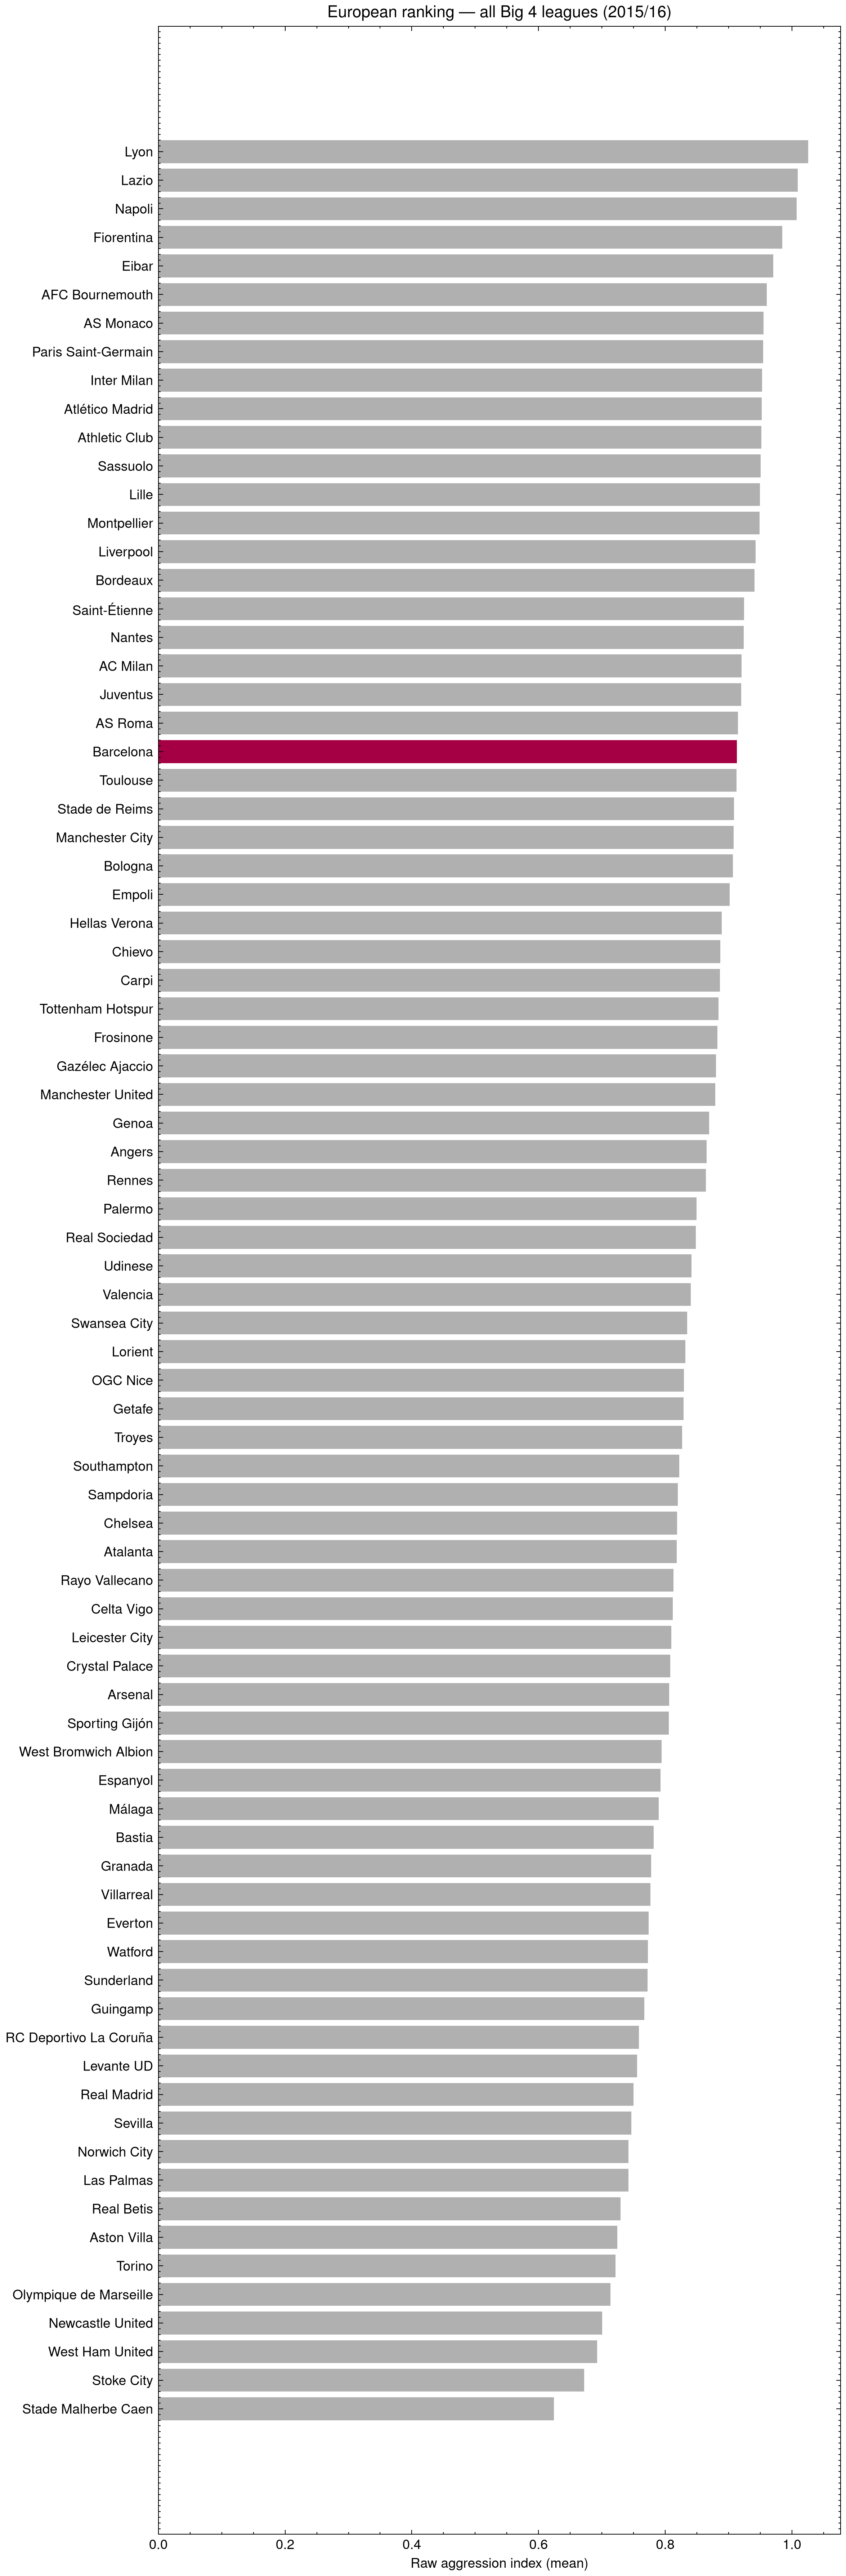

In [23]:
plot_ranked_bar(
    overall_ranking,
    "European ranking — all Big 4 leagues (2015/16)",
    "Raw aggression index (mean)",
)

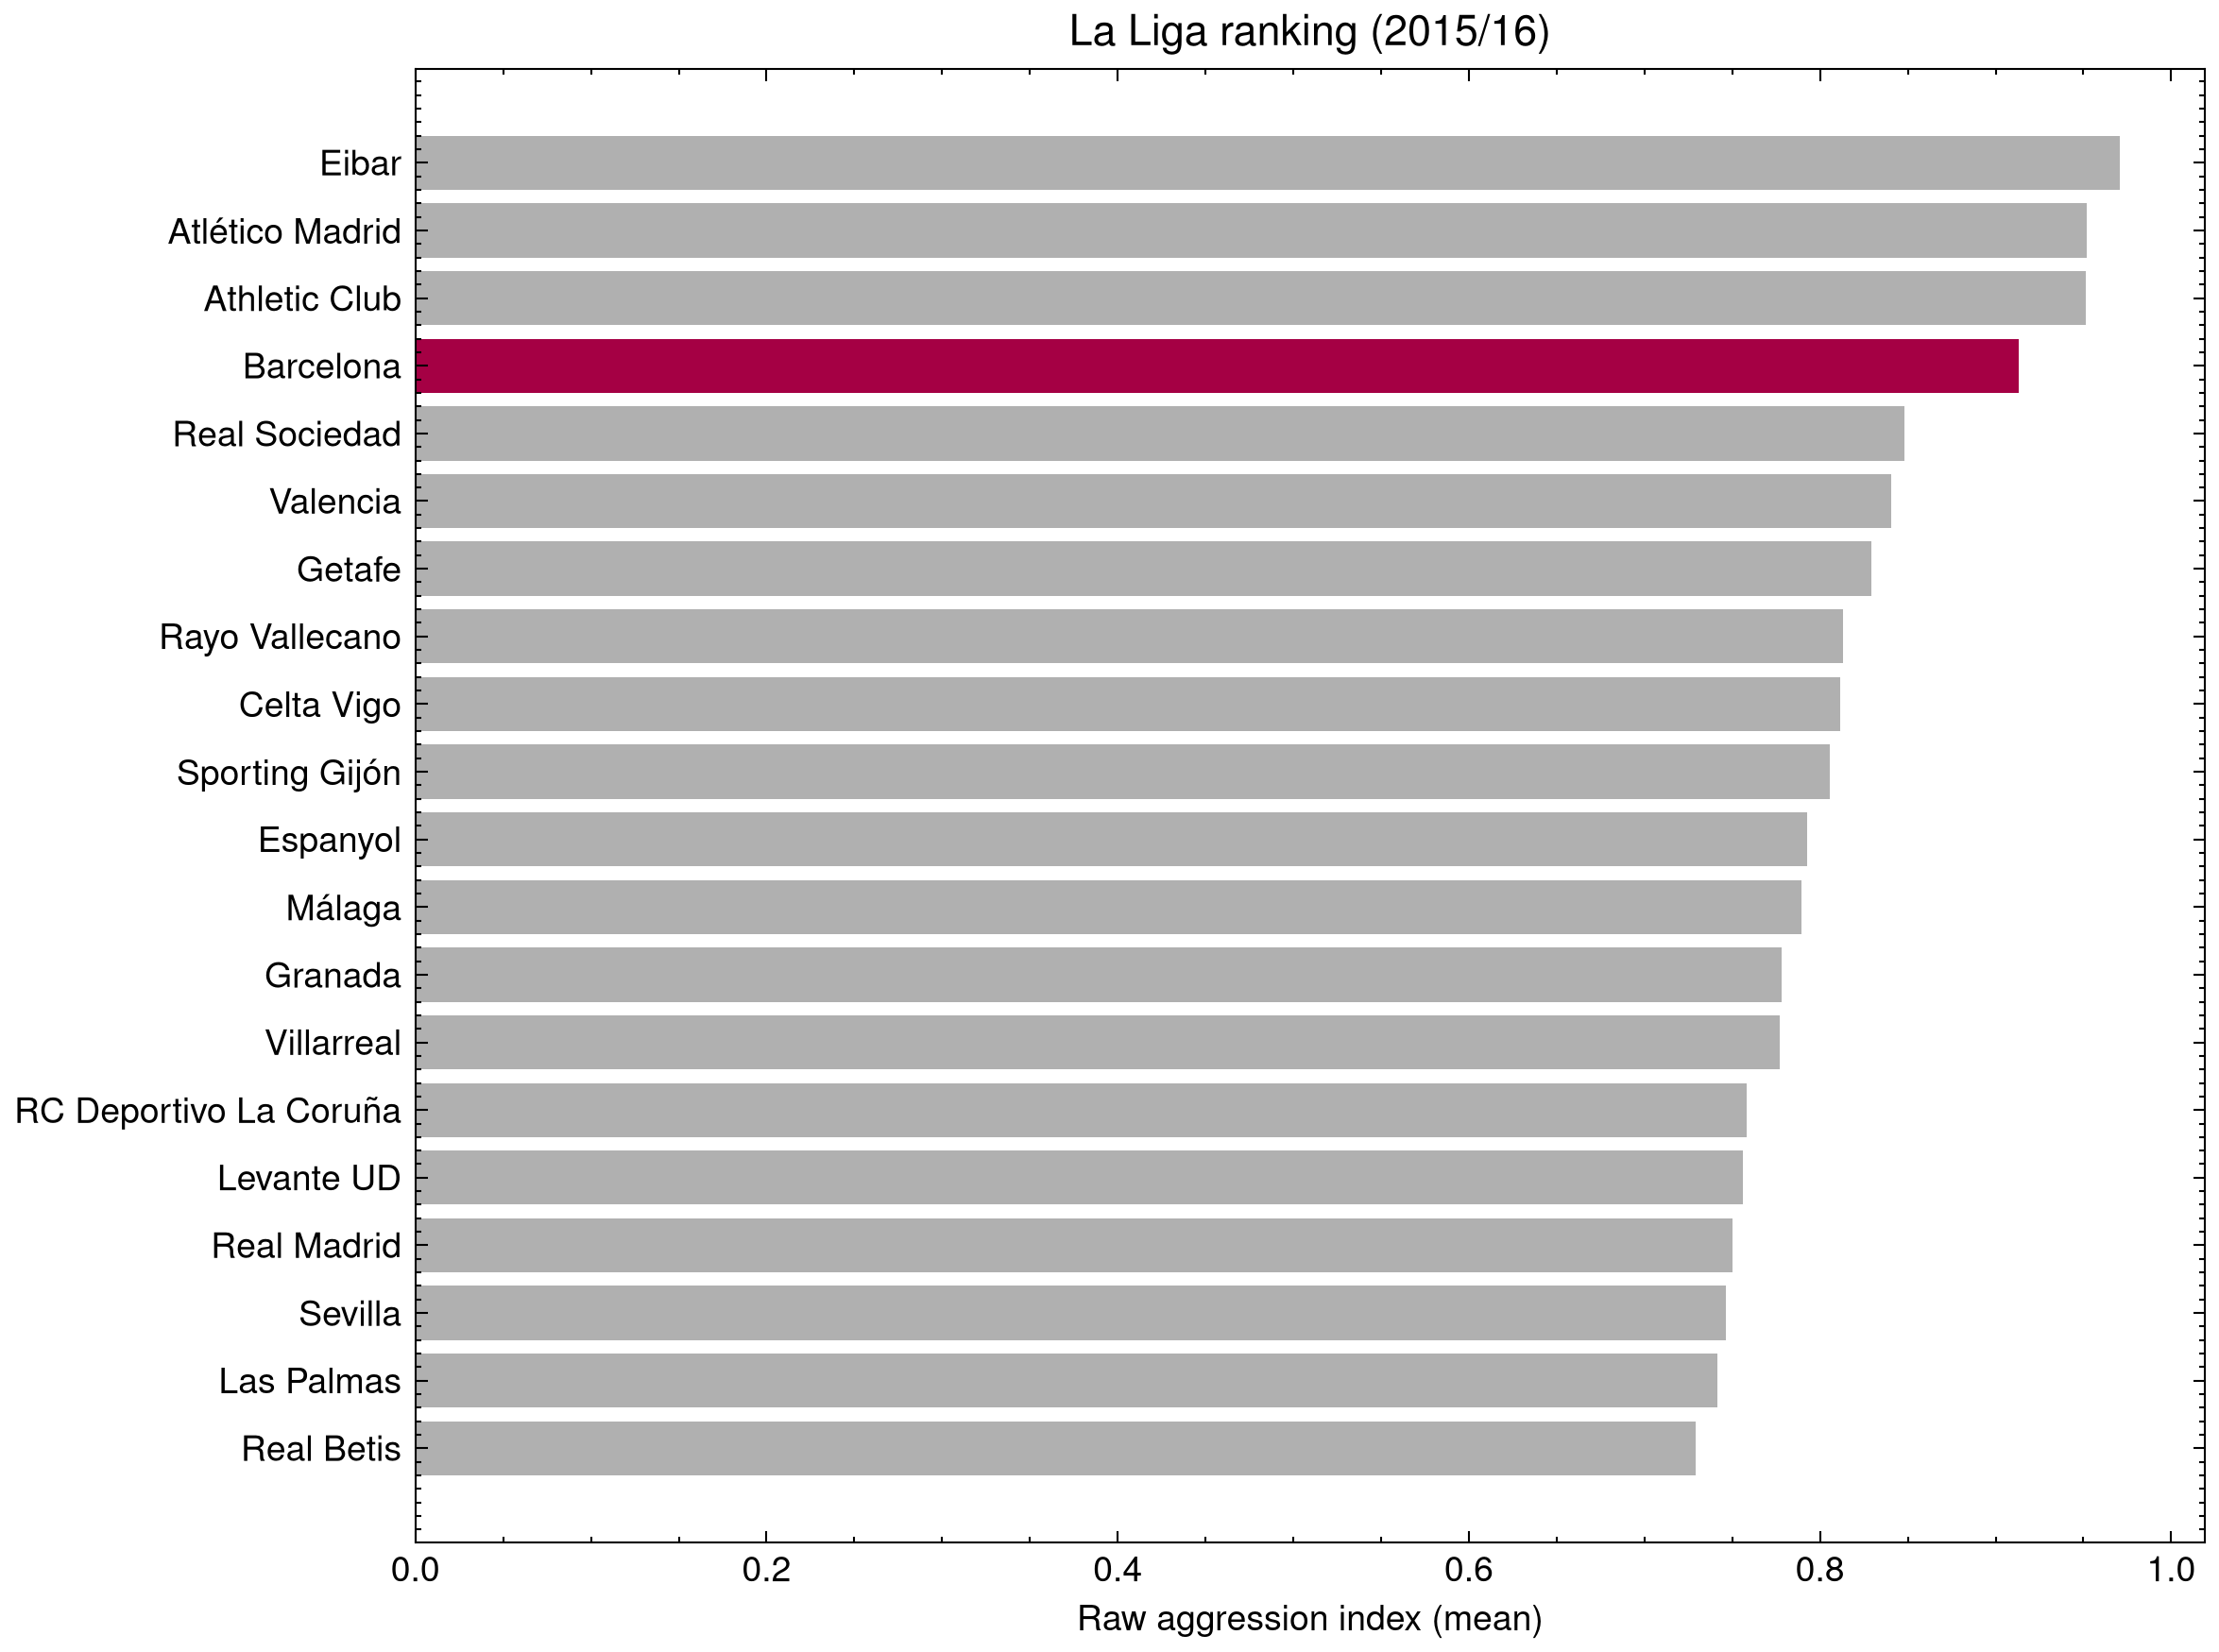

In [24]:
plot_ranked_bar(
    la_liga_ranking,
    "La Liga ranking (2015/16)",
    "Raw aggression index (mean)",
)

# Why is Barcelona lower than expected

Two live hypotheses, not mutually exclusive. First, Barcelona's positional/passing-lane control may prevent opponents from ever reaching a contestable 50/50 as often as against other teams, so they win the ball back through fewer, cleaner interceptions rather than repeated physical engagement — a genuine tactical difference the metric is correctly picking up, not an artifact. Note that normalizing by opponent possessions corrects for *opportunity* (how many times the opponent had the ball) but does not cancel out genuine differences in the numerator — if Barcelona generates fewer attempt-events per opponent possession, that's a real signal, not something the ratio washes out. Second, Barcelona's opponents have unusually few, long possessions when Barcelona dominate a match, which makes the per-match rate noisier (a smaller denominator inflates variance) — investigated below.

# Denominator and variance check (La Liga)

The main CSVs only store the final `raw_aggression_index` ratio, not the raw `opponent_possessions` denominator behind it, so this recomputes it from the event data for every La Liga match — cached to `data/la_liga_diagnostics.csv` so it only needs to run once.

In [25]:
def compute_diagnostics_for_match(match_id, home_team, away_team):
    events = sb.events(match_id=match_id)
    loc_x = _loc_x(events)
    rows = []
    for team, opponent, venue in [(home_team, away_team, "Home"), (away_team, home_team, "Away")]:
        attempts = (
            (events["team"] == team) & _is_defensive_action_attempt(events)
            & loc_x.notna() & (loc_x > 60)
        ).sum()
        opponent_possessions = events.loc[events["possession_team"] == opponent, "possession"].nunique()
        rate = attempts / opponent_possessions if opponent_possessions > 0 else np.nan
        rows.append({
            "match_id": match_id,
            "team": team,
            "opponent": opponent,
            "venue": venue,
            "attempts": attempts,
            "opponent_possessions": opponent_possessions,
            "rate": rate,
        })
    return rows


la_liga_diagnostics_path = "data/la_liga_diagnostics.csv"

if os.path.exists(la_liga_diagnostics_path):
    la_liga_diagnostics_df = pd.read_csv(la_liga_diagnostics_path)
else:
    la_liga_matches = sb.matches(competition_id=11, season_id=27)
    diagnostic_rows = []
    for _, m in la_liga_matches.iterrows():
        diagnostic_rows.extend(compute_diagnostics_for_match(m["match_id"], m["home_team"], m["away_team"]))
    la_liga_diagnostics_df = pd.DataFrame(diagnostic_rows)
    la_liga_diagnostics_df.to_csv(la_liga_diagnostics_path, index=False)

la_liga_diagnostics_df.head()

,match_id,team,opponent,venue,attempts,opponent_possessions,rate
0,3825739,Real Madrid,Sporting Gijón,Home,71,99,0.717172
1,3825739,Sporting Gijón,Real Madrid,Away,63,97,0.649485
2,3825848,Levante UD,Eibar,Home,74,92,0.804348
3,3825848,Eibar,Levante UD,Away,84,115,0.730435
4,3825895,Las Palmas,Sevilla,Home,64,94,0.680851


In [26]:
diagnostics_summary = la_liga_diagnostics_df.groupby(["team", "venue"]).agg(
    mean_opponent_possessions=("opponent_possessions", "mean"),
    std_rate=("rate", "std"),
    mean_rate=("rate", "mean"),
).reset_index()

home_summary = diagnostics_summary[diagnostics_summary["venue"] == "Home"].set_index("team").drop(columns="venue")
away_summary = diagnostics_summary[diagnostics_summary["venue"] == "Away"].set_index("team").drop(columns="venue")

home_summary.sort_values("mean_opponent_possessions")

,mean_opponent_possessions,std_rate,mean_rate
team,,,
Barcelona,84.368421,0.258727,0.952323
Real Betis,92.842105,0.227095,0.874167
Las Palmas,93.105263,0.223560,0.792965
Celta Vigo,93.842105,0.227569,0.892248
RC Deportivo La Coruña,95.052632,0.191476,0.856899
Atlético Madrid,97.000000,0.256708,1.044125
Sevilla,97.263158,0.238192,0.824432
Sporting Gijón,97.684211,0.196380,0.845897
Villarreal,97.947368,0.222345,0.821733


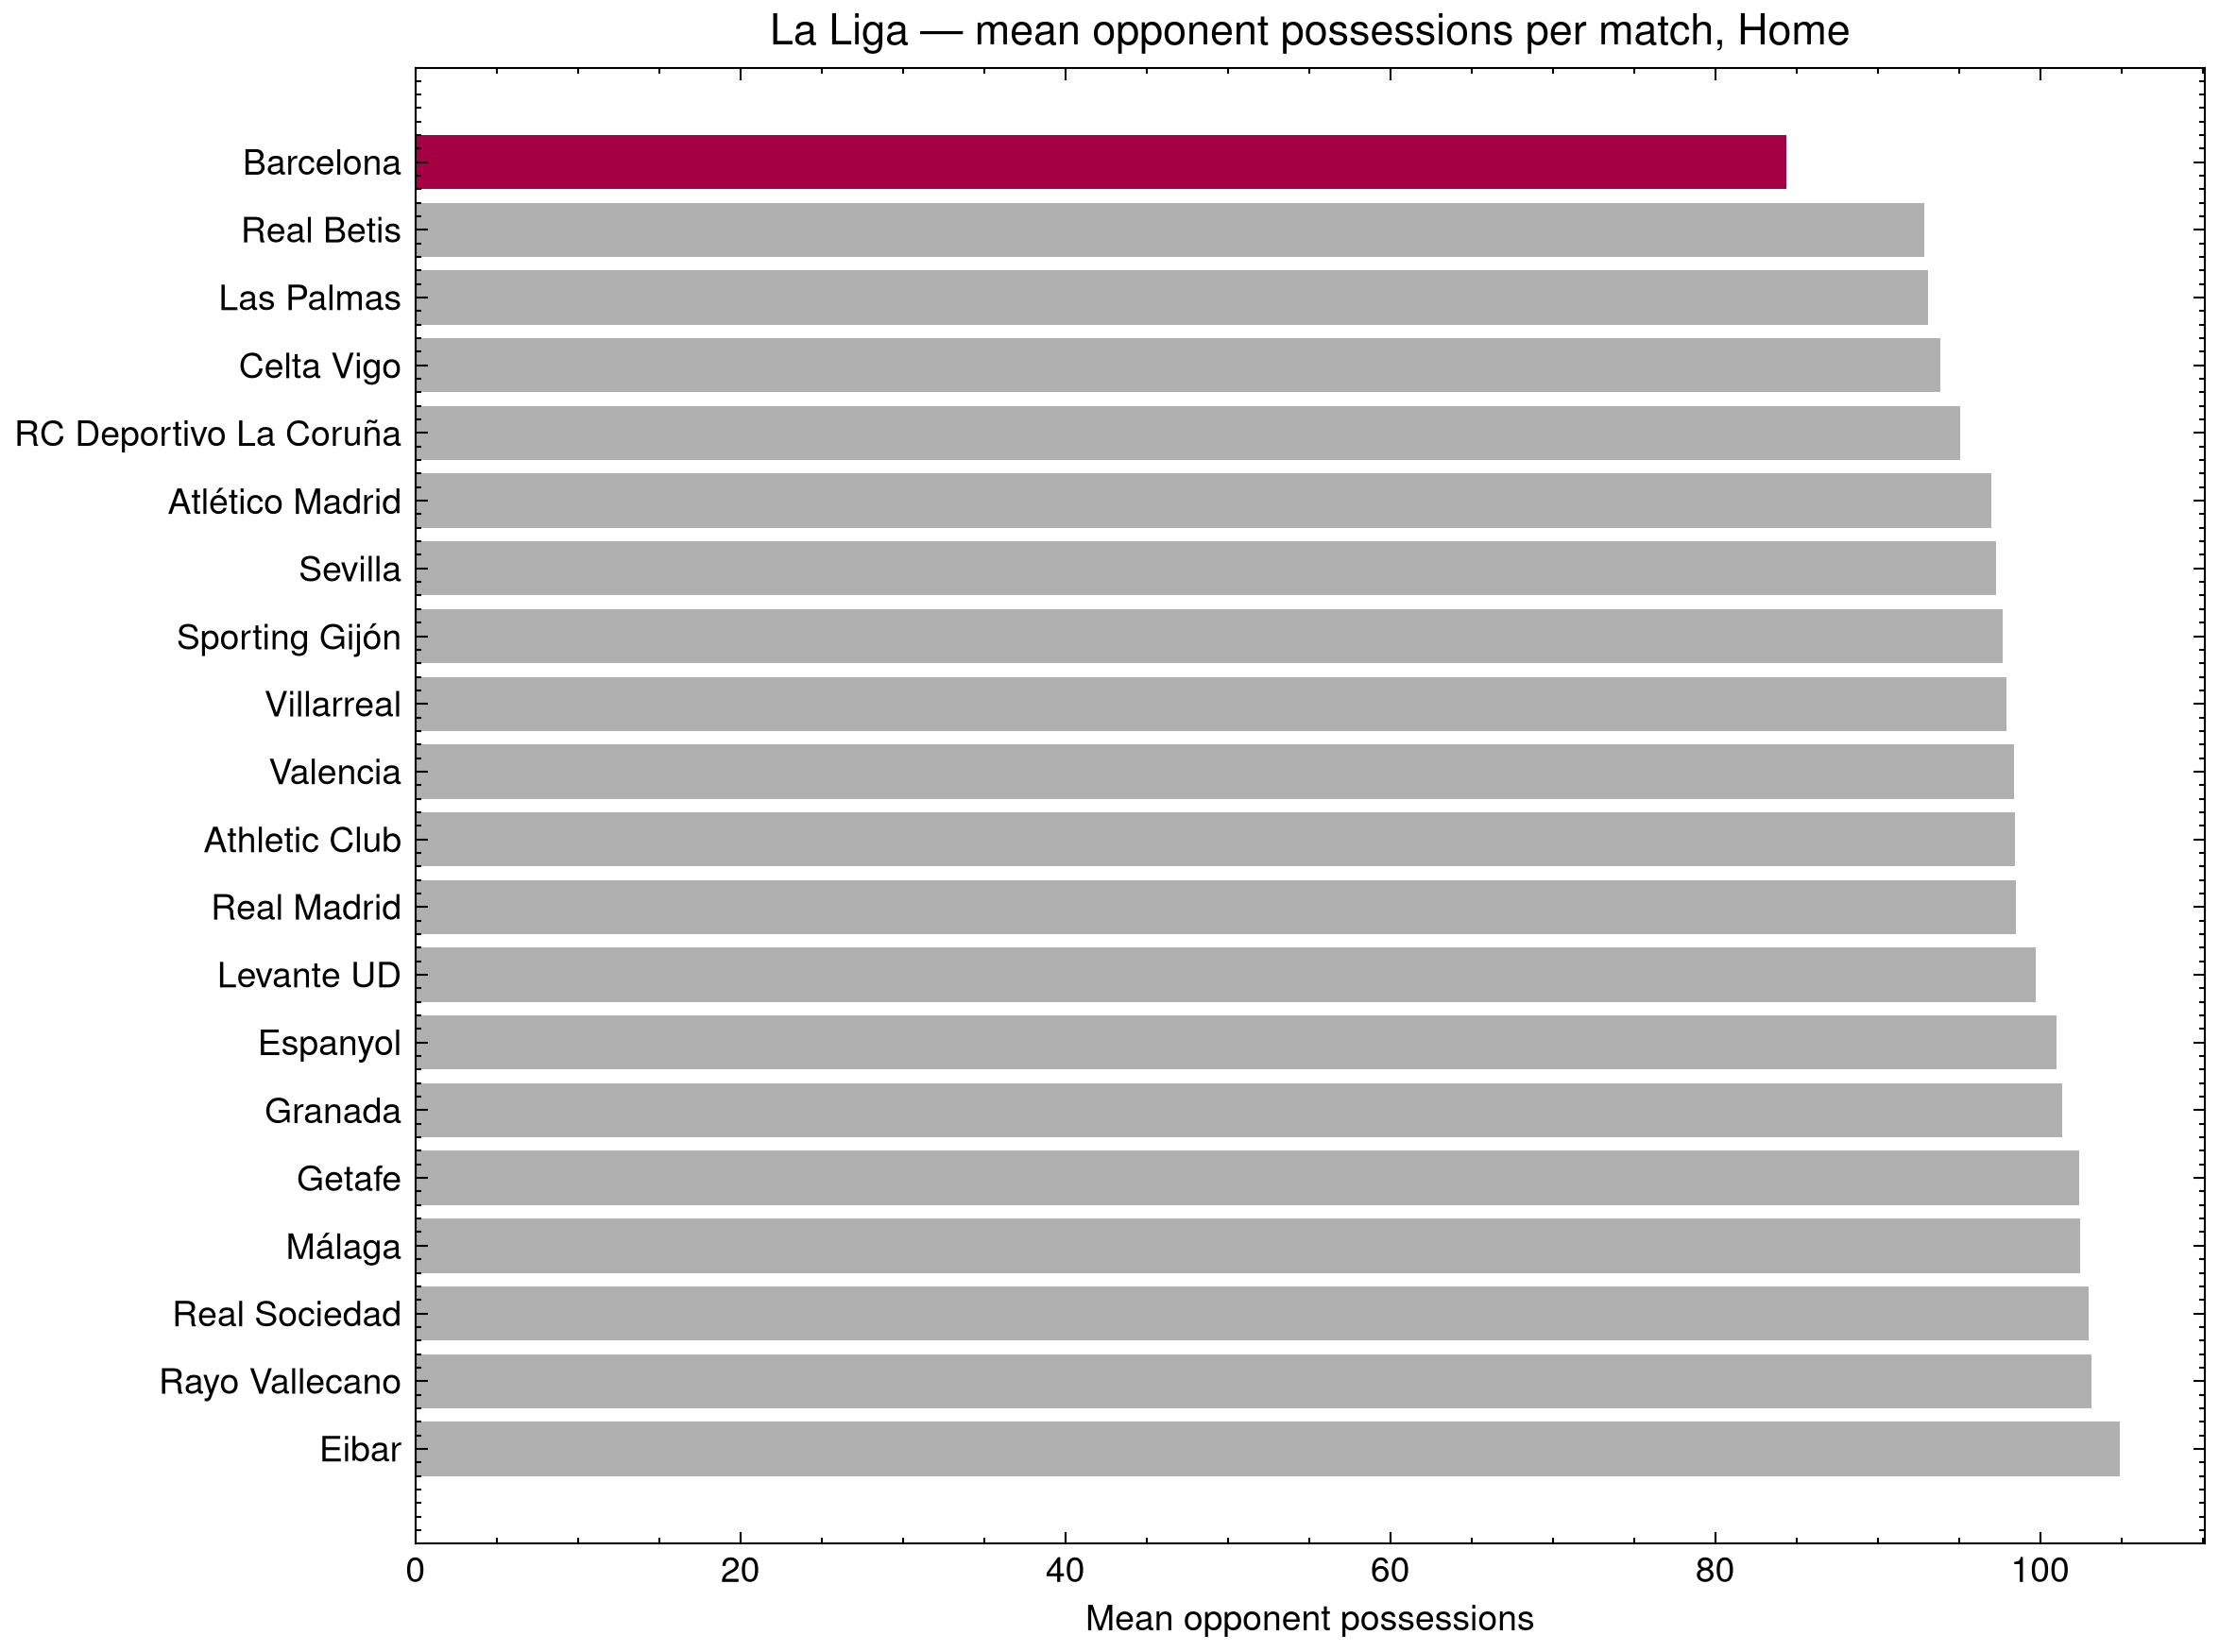

In [27]:
plot_ranked_bar(
    home_summary["mean_opponent_possessions"].sort_values(),
    "La Liga — mean opponent possessions per match, Home",
    "Mean opponent possessions",
)

In [28]:
away_summary.sort_values("mean_opponent_possessions")

,mean_opponent_possessions,std_rate,mean_rate
team,,,
Barcelona,84.473684,0.291909,0.873563
Real Madrid,92.894737,0.209643,0.741825
Las Palmas,96.526316,0.208024,0.690404
Celta Vigo,98.578947,0.177108,0.731096
Getafe,98.631579,0.153313,0.815696
Sevilla,99.526316,0.114489,0.668030
Atlético Madrid,99.578947,0.201999,0.859928
Real Betis,100.263158,0.167908,0.584430
Espanyol,101.421053,0.217409,0.703650


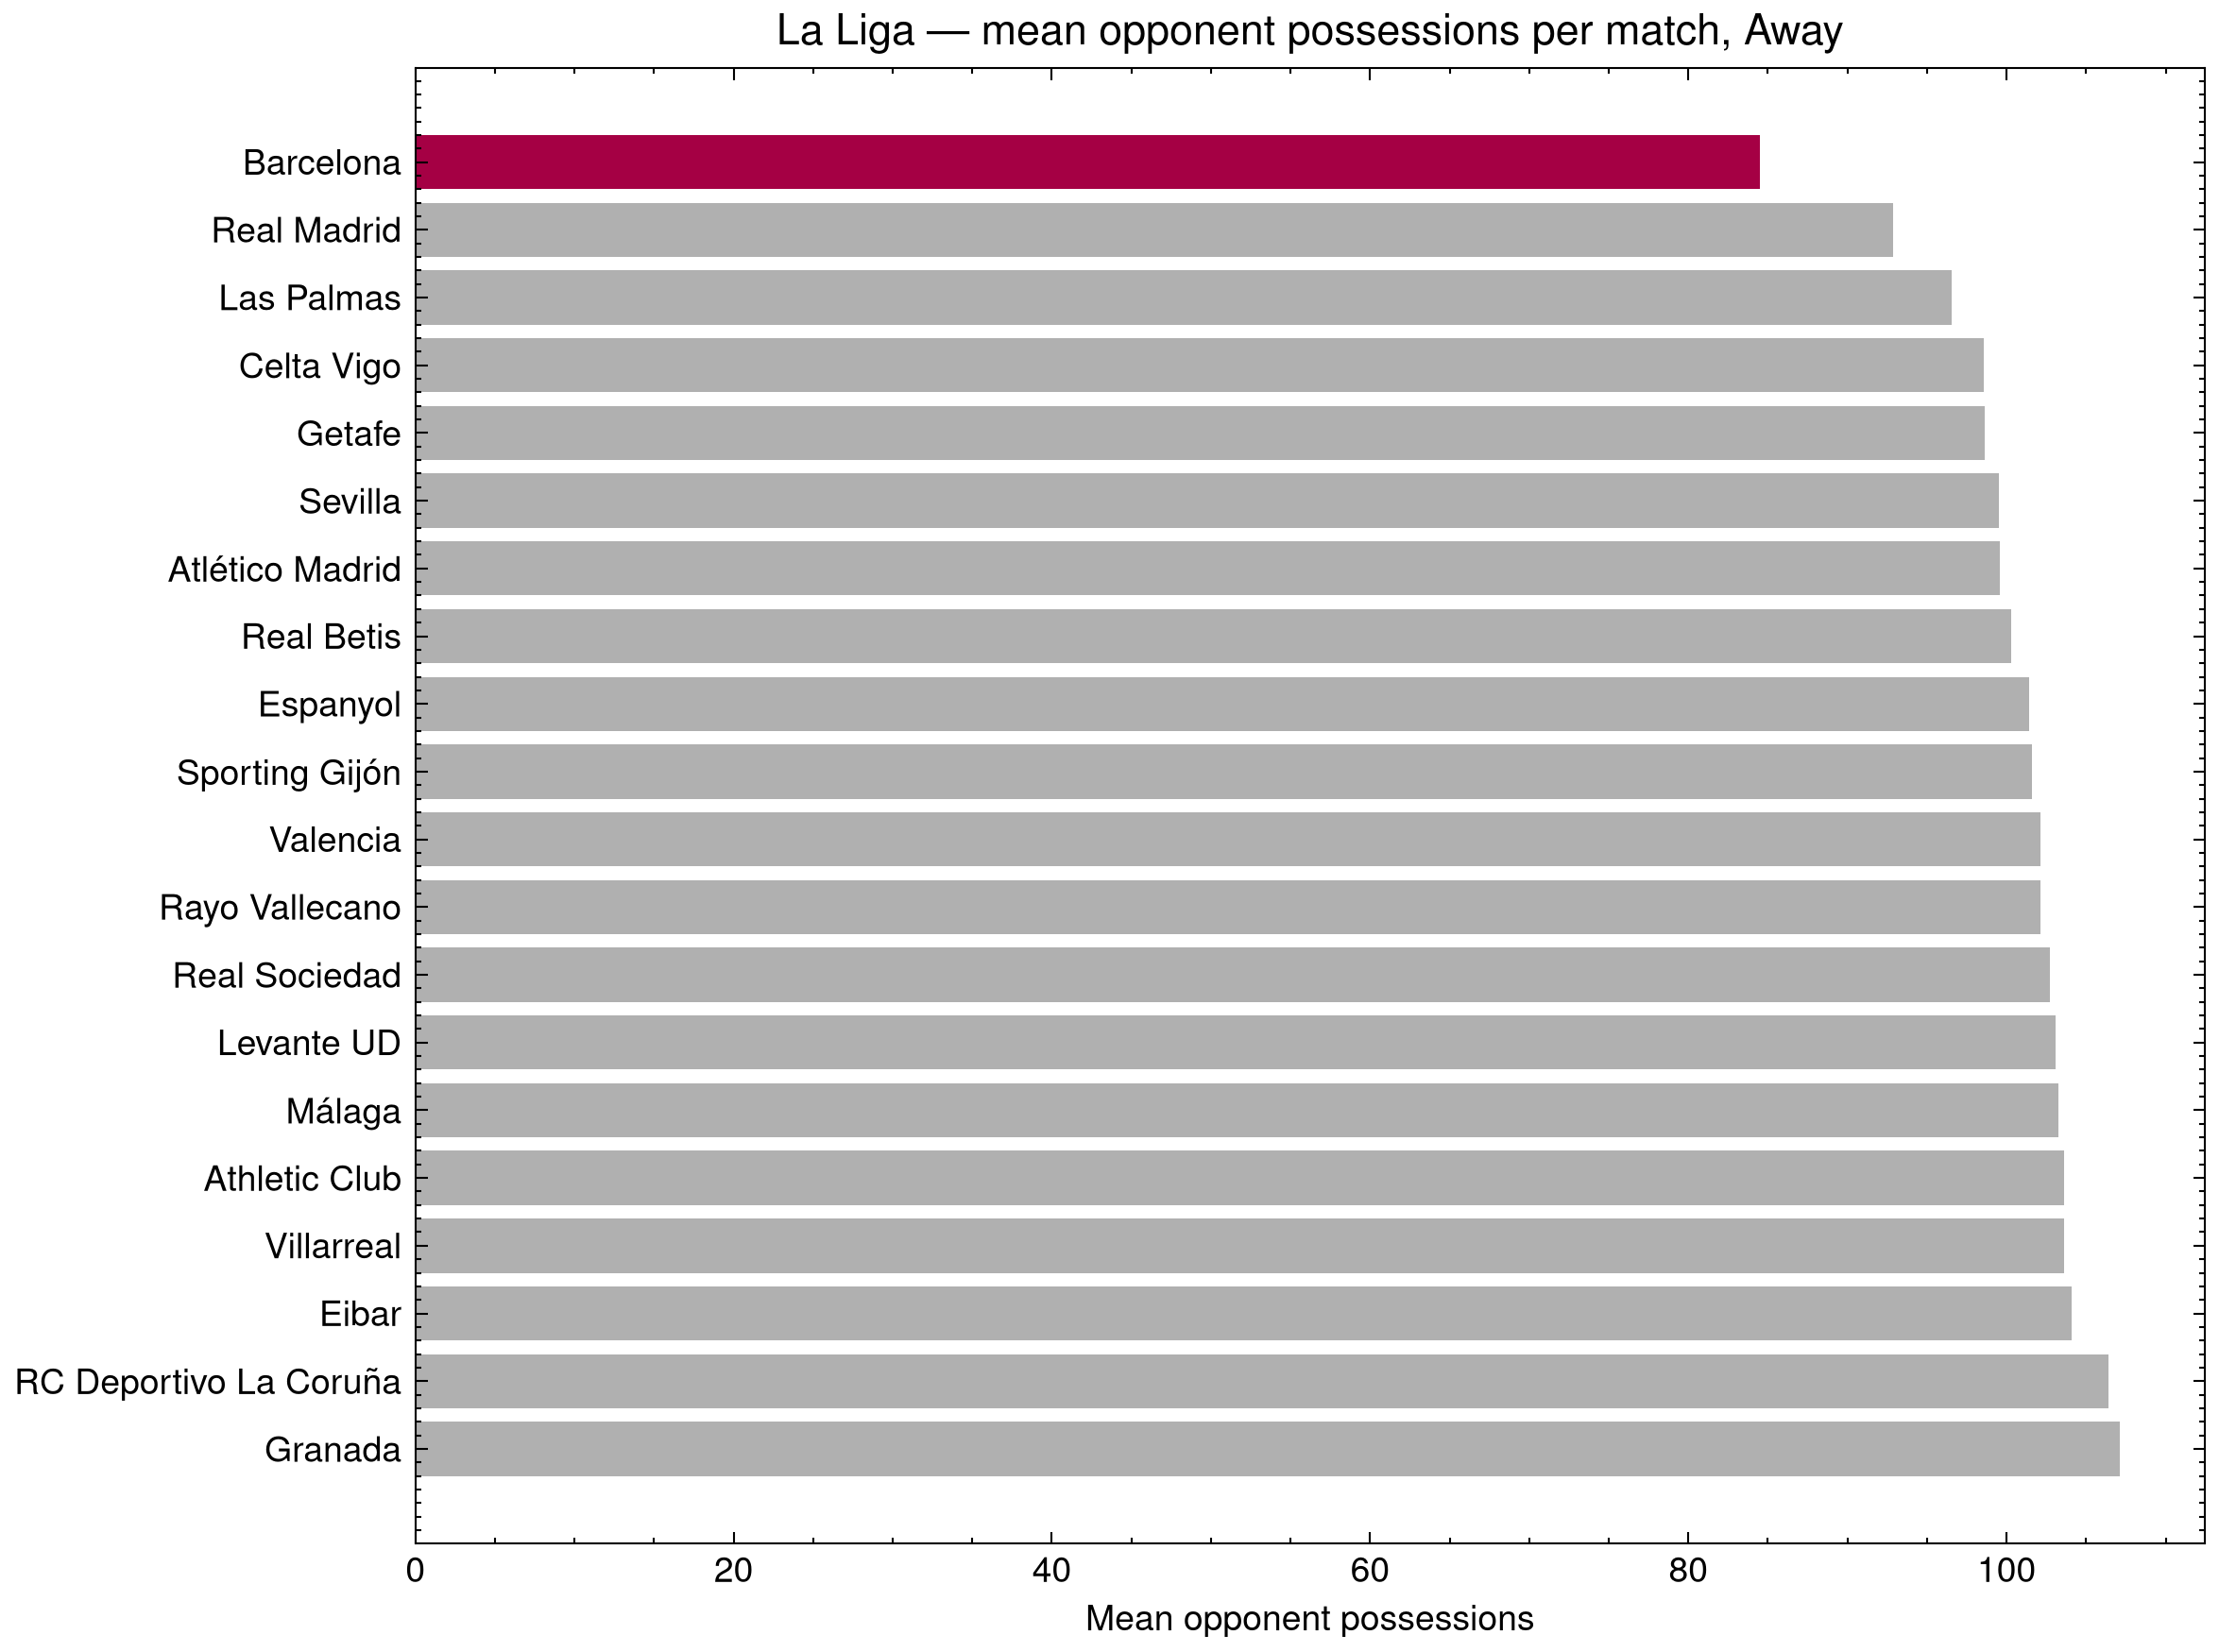

In [29]:
plot_ranked_bar(
    away_summary["mean_opponent_possessions"].sort_values(),
    "La Liga — mean opponent possessions per match, Away",
    "Mean opponent possessions",
)

In [30]:
print("Home: corr(mean_opponent_possessions, std_rate) =", round(home_summary["mean_opponent_possessions"].corr(home_summary["std_rate"]), 3))
print("Away: corr(mean_opponent_possessions, std_rate) =", round(away_summary["mean_opponent_possessions"].corr(away_summary["std_rate"]), 3))

Home: corr(mean_opponent_possessions, std_rate) = -0.141
Away: corr(mean_opponent_possessions, std_rate) = -0.225


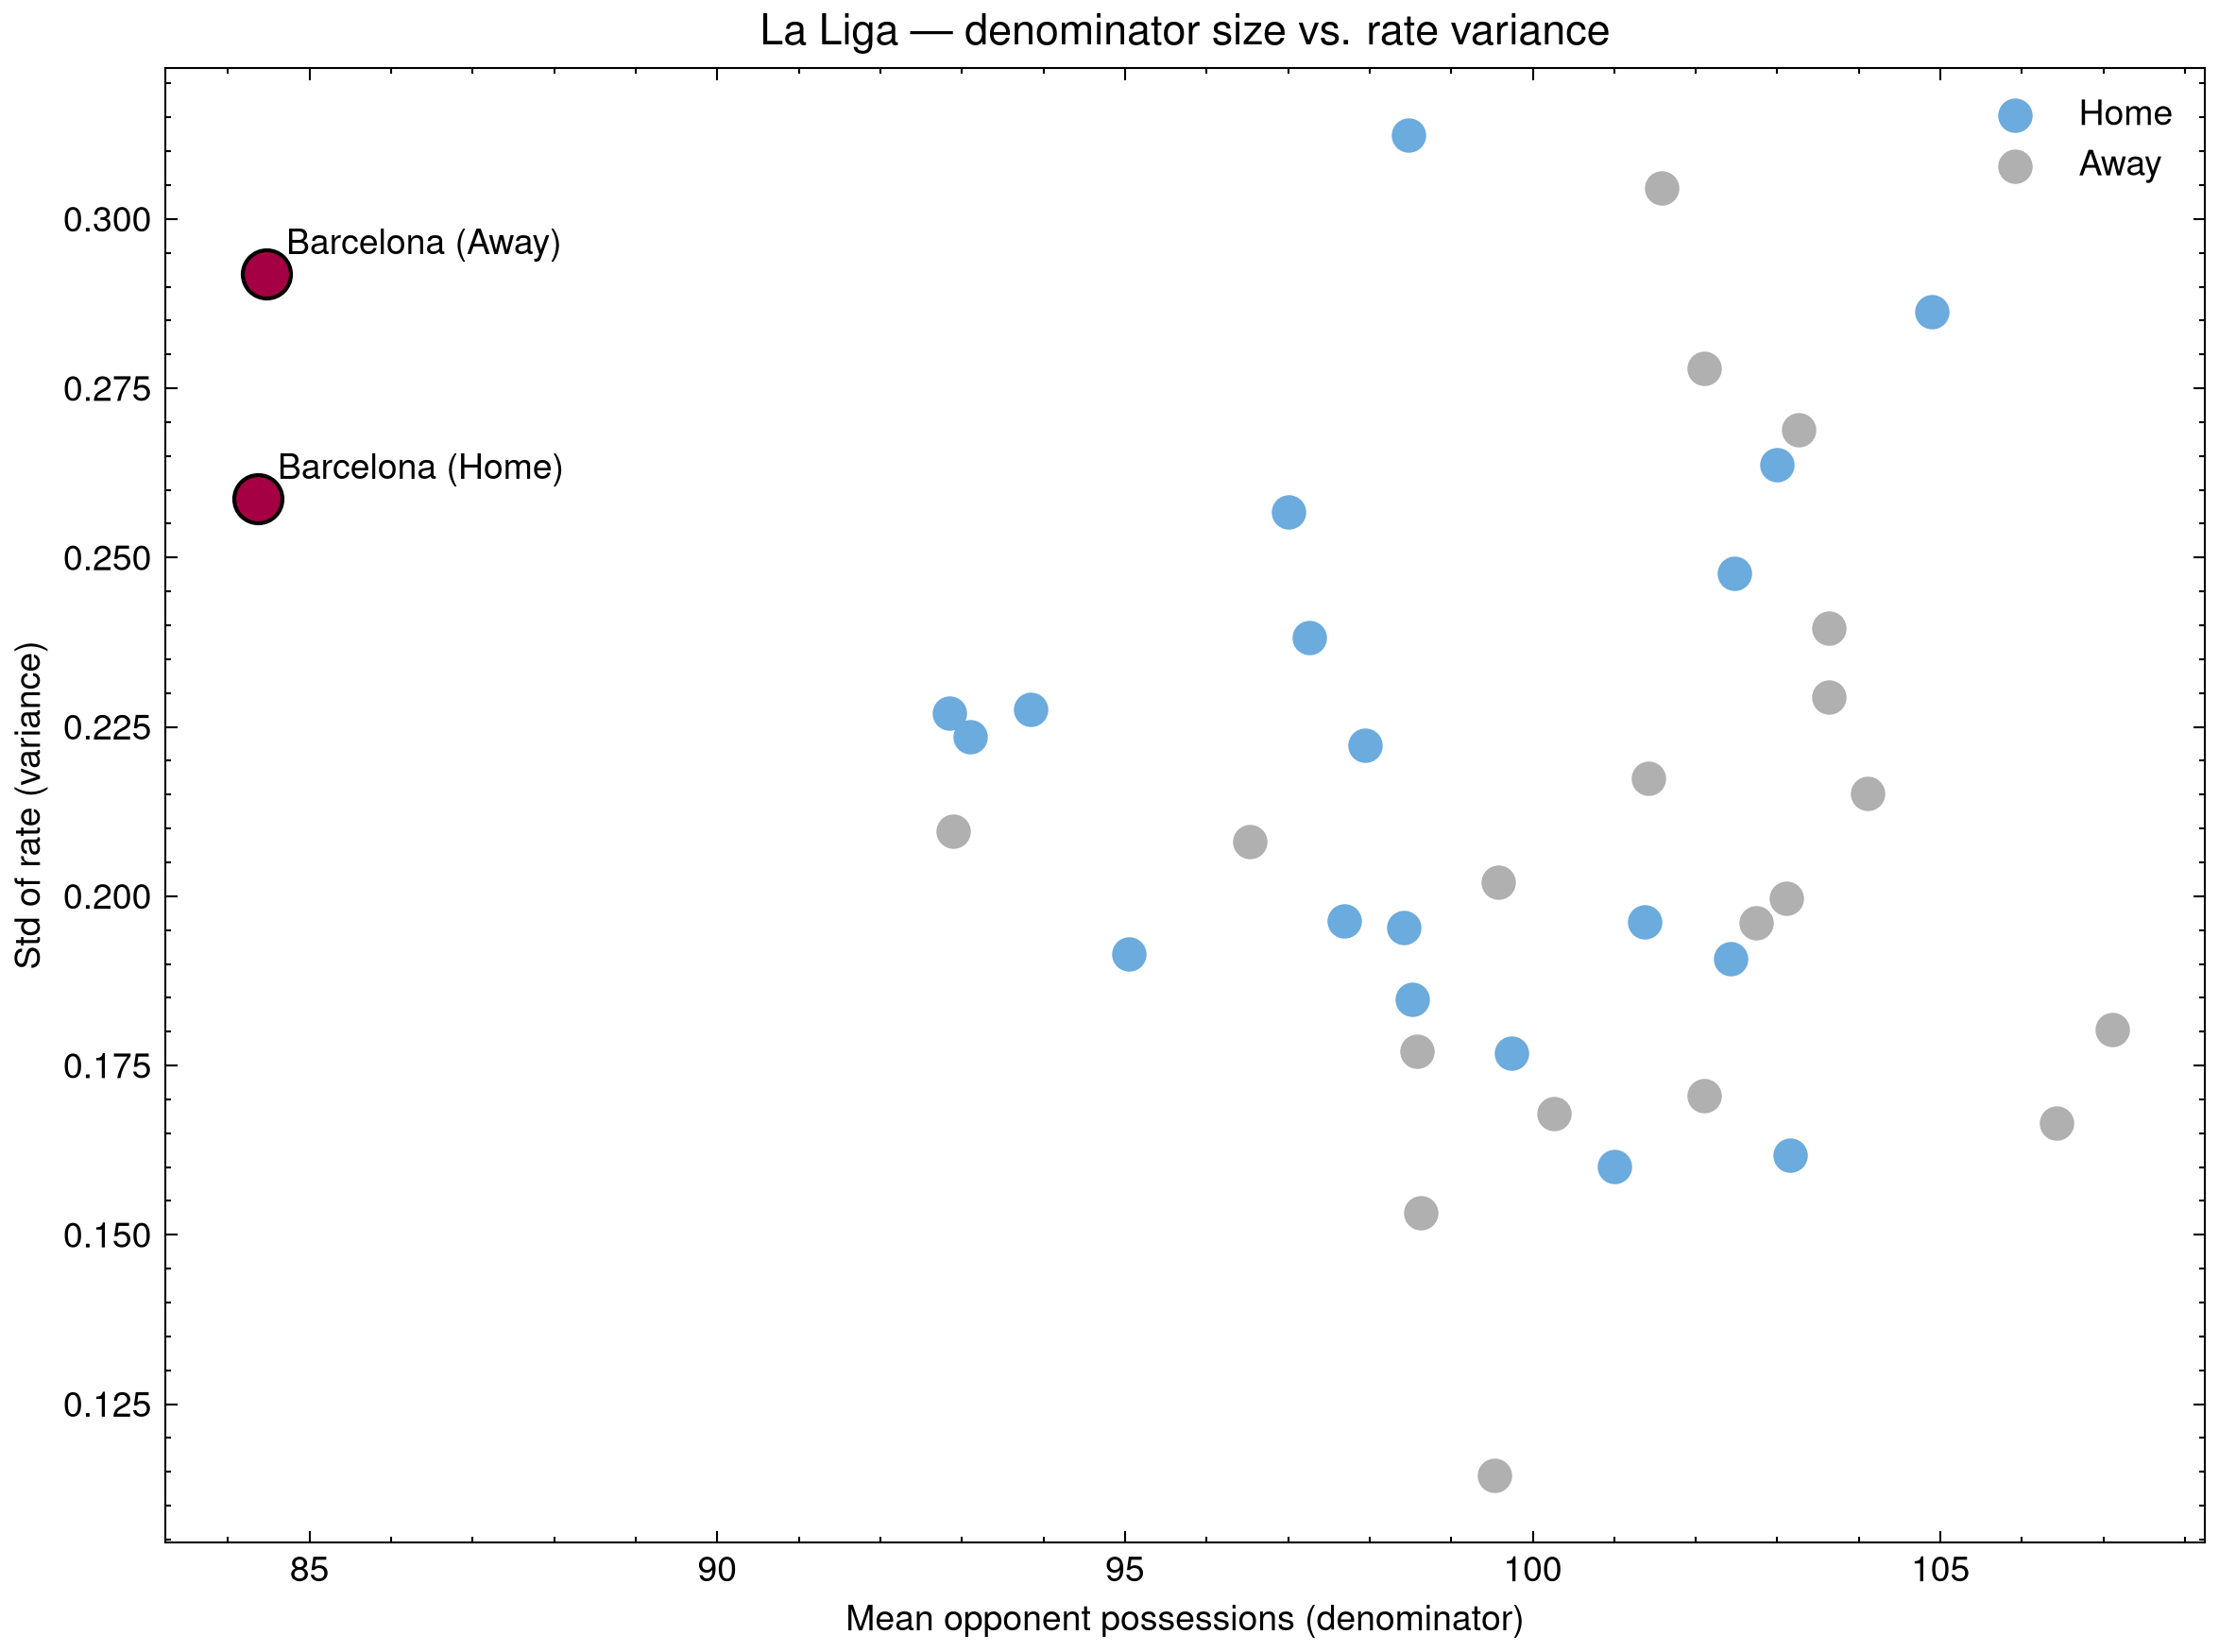

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(home_summary["mean_opponent_possessions"], home_summary["std_rate"], color="#6CABDD", label="Home", s=60)
plt.scatter(away_summary["mean_opponent_possessions"], away_summary["std_rate"], color="#B0B0B0", label="Away", s=60)

plt.scatter(
    home_summary.loc["Barcelona", "mean_opponent_possessions"], home_summary.loc["Barcelona", "std_rate"],
    color="#A50044", s=150, edgecolor="black", zorder=5,
)
plt.scatter(
    away_summary.loc["Barcelona", "mean_opponent_possessions"], away_summary.loc["Barcelona", "std_rate"],
    color="#A50044", s=150, edgecolor="black", zorder=5,
)
plt.annotate(
    "Barcelona (Home)",
    (home_summary.loc["Barcelona", "mean_opponent_possessions"], home_summary.loc["Barcelona", "std_rate"]),
    textcoords="offset points", xytext=(5, 5),
)
plt.annotate(
    "Barcelona (Away)",
    (away_summary.loc["Barcelona", "mean_opponent_possessions"], away_summary.loc["Barcelona", "std_rate"]),
    textcoords="offset points", xytext=(5, 5),
)

plt.xlabel("Mean opponent possessions (denominator)")
plt.ylabel("Std of rate (variance)")
plt.title("La Liga — denominator size vs. rate variance")
plt.legend()
plt.tight_layout()
plt.show()

# Barcelona vs. league average

Barcelona's opponents average the fewest possessions per match in the league by a clear margin, and Barcelona's own rate variance is elevated in both venues — more so away than home. A back-of-envelope check: for a ratio, standard deviation scales roughly as `1 / denominator` holding the numerator's own variability fixed, so a ~15–17% smaller denominator predicts roughly a ~19% increase in std from that effect alone. That accounts for almost the entire home gap, but only about half of the away gap — something else is adding extra variance specifically away.

In [32]:
league_avg_home = home_summary.drop("Barcelona").mean()
league_avg_away = away_summary.drop("Barcelona").mean()

print("Barcelona home:", home_summary.loc["Barcelona"].round(3).to_dict())
print("League avg home (excl. Barcelona):", league_avg_home.round(3).to_dict())
print()
print("Barcelona away:", away_summary.loc["Barcelona"].round(3).to_dict())
print("League avg away (excl. Barcelona):", league_avg_away.round(3).to_dict())

Barcelona home: {'mean_opponent_possessions': 84.368, 'std_rate': 0.259, 'mean_rate': 0.952}
League avg home (excl. Barcelona): {'mean_opponent_possessions': 98.853, 'std_rate': 0.219, 'mean_rate': 0.864}

Barcelona away: {'mean_opponent_possessions': 84.474, 'std_rate': 0.292, 'mean_rate': 0.874}
League avg away (excl. Barcelona): {'mean_opponent_possessions': 101.432, 'std_rate': 0.205, 'mean_rate': 0.761}


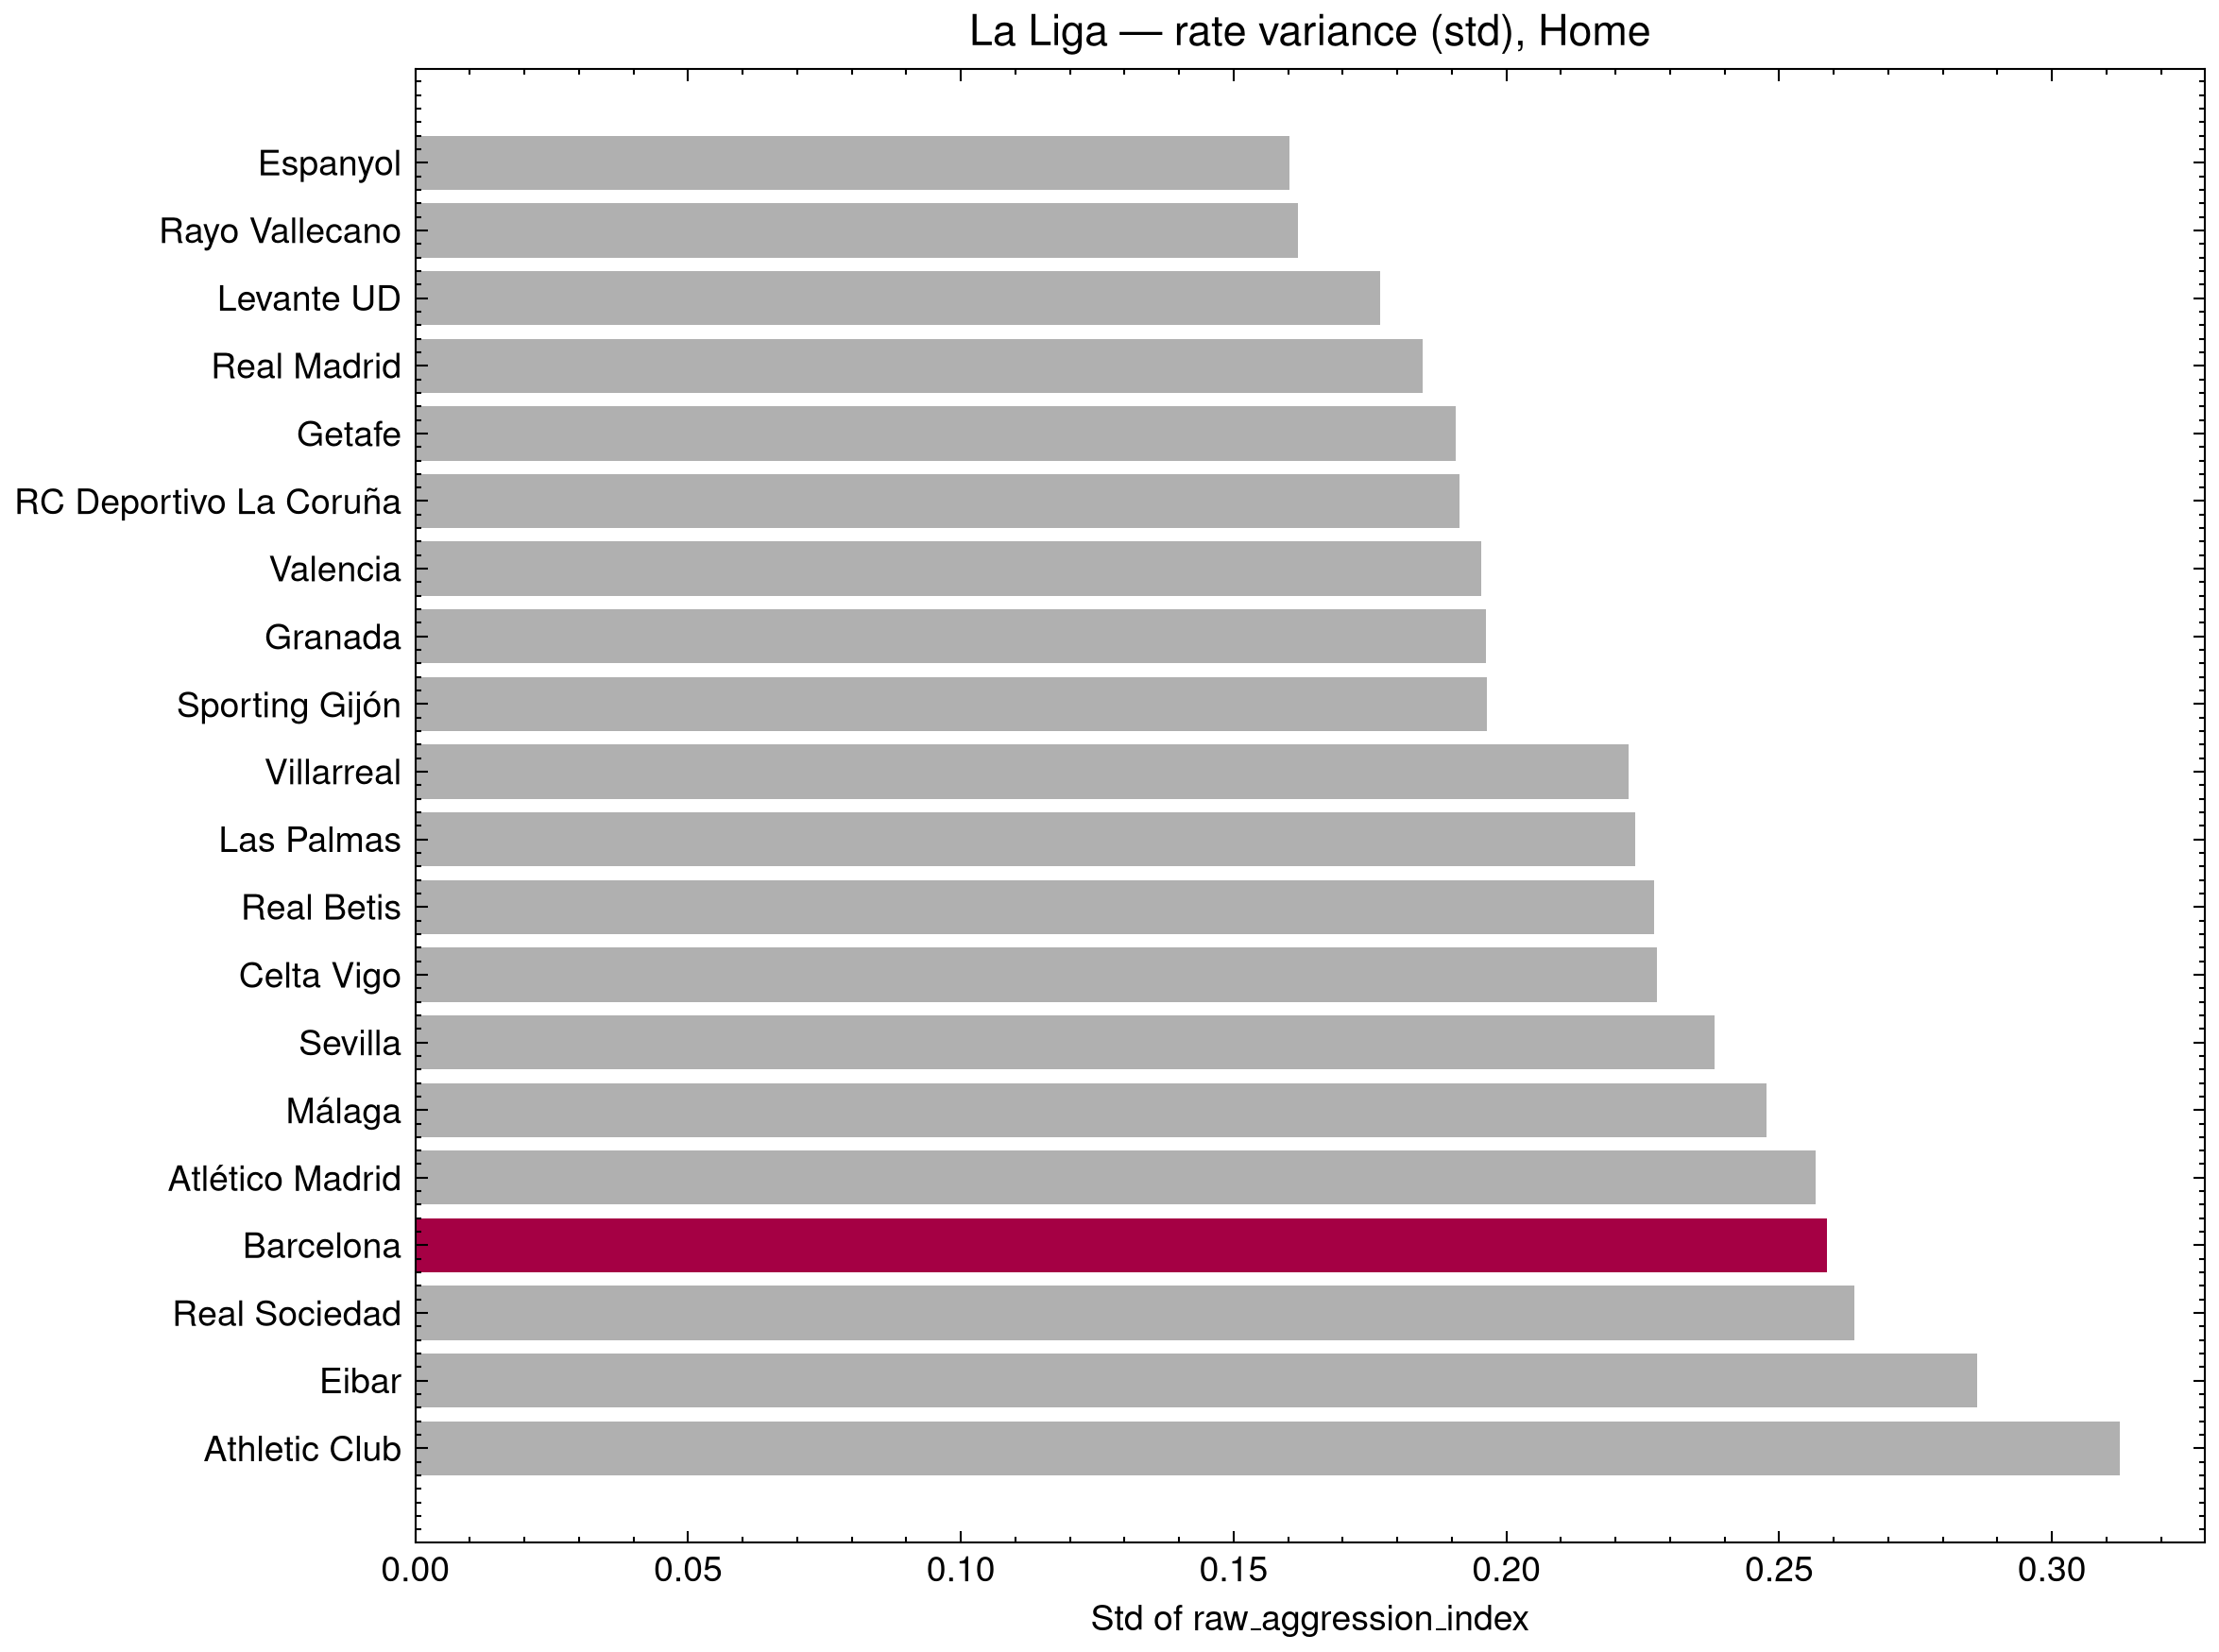

In [33]:
plot_ranked_bar(
    home_summary["std_rate"].sort_values(),
    "La Liga — rate variance (std), Home",
    "Std of raw_aggression_index",
)

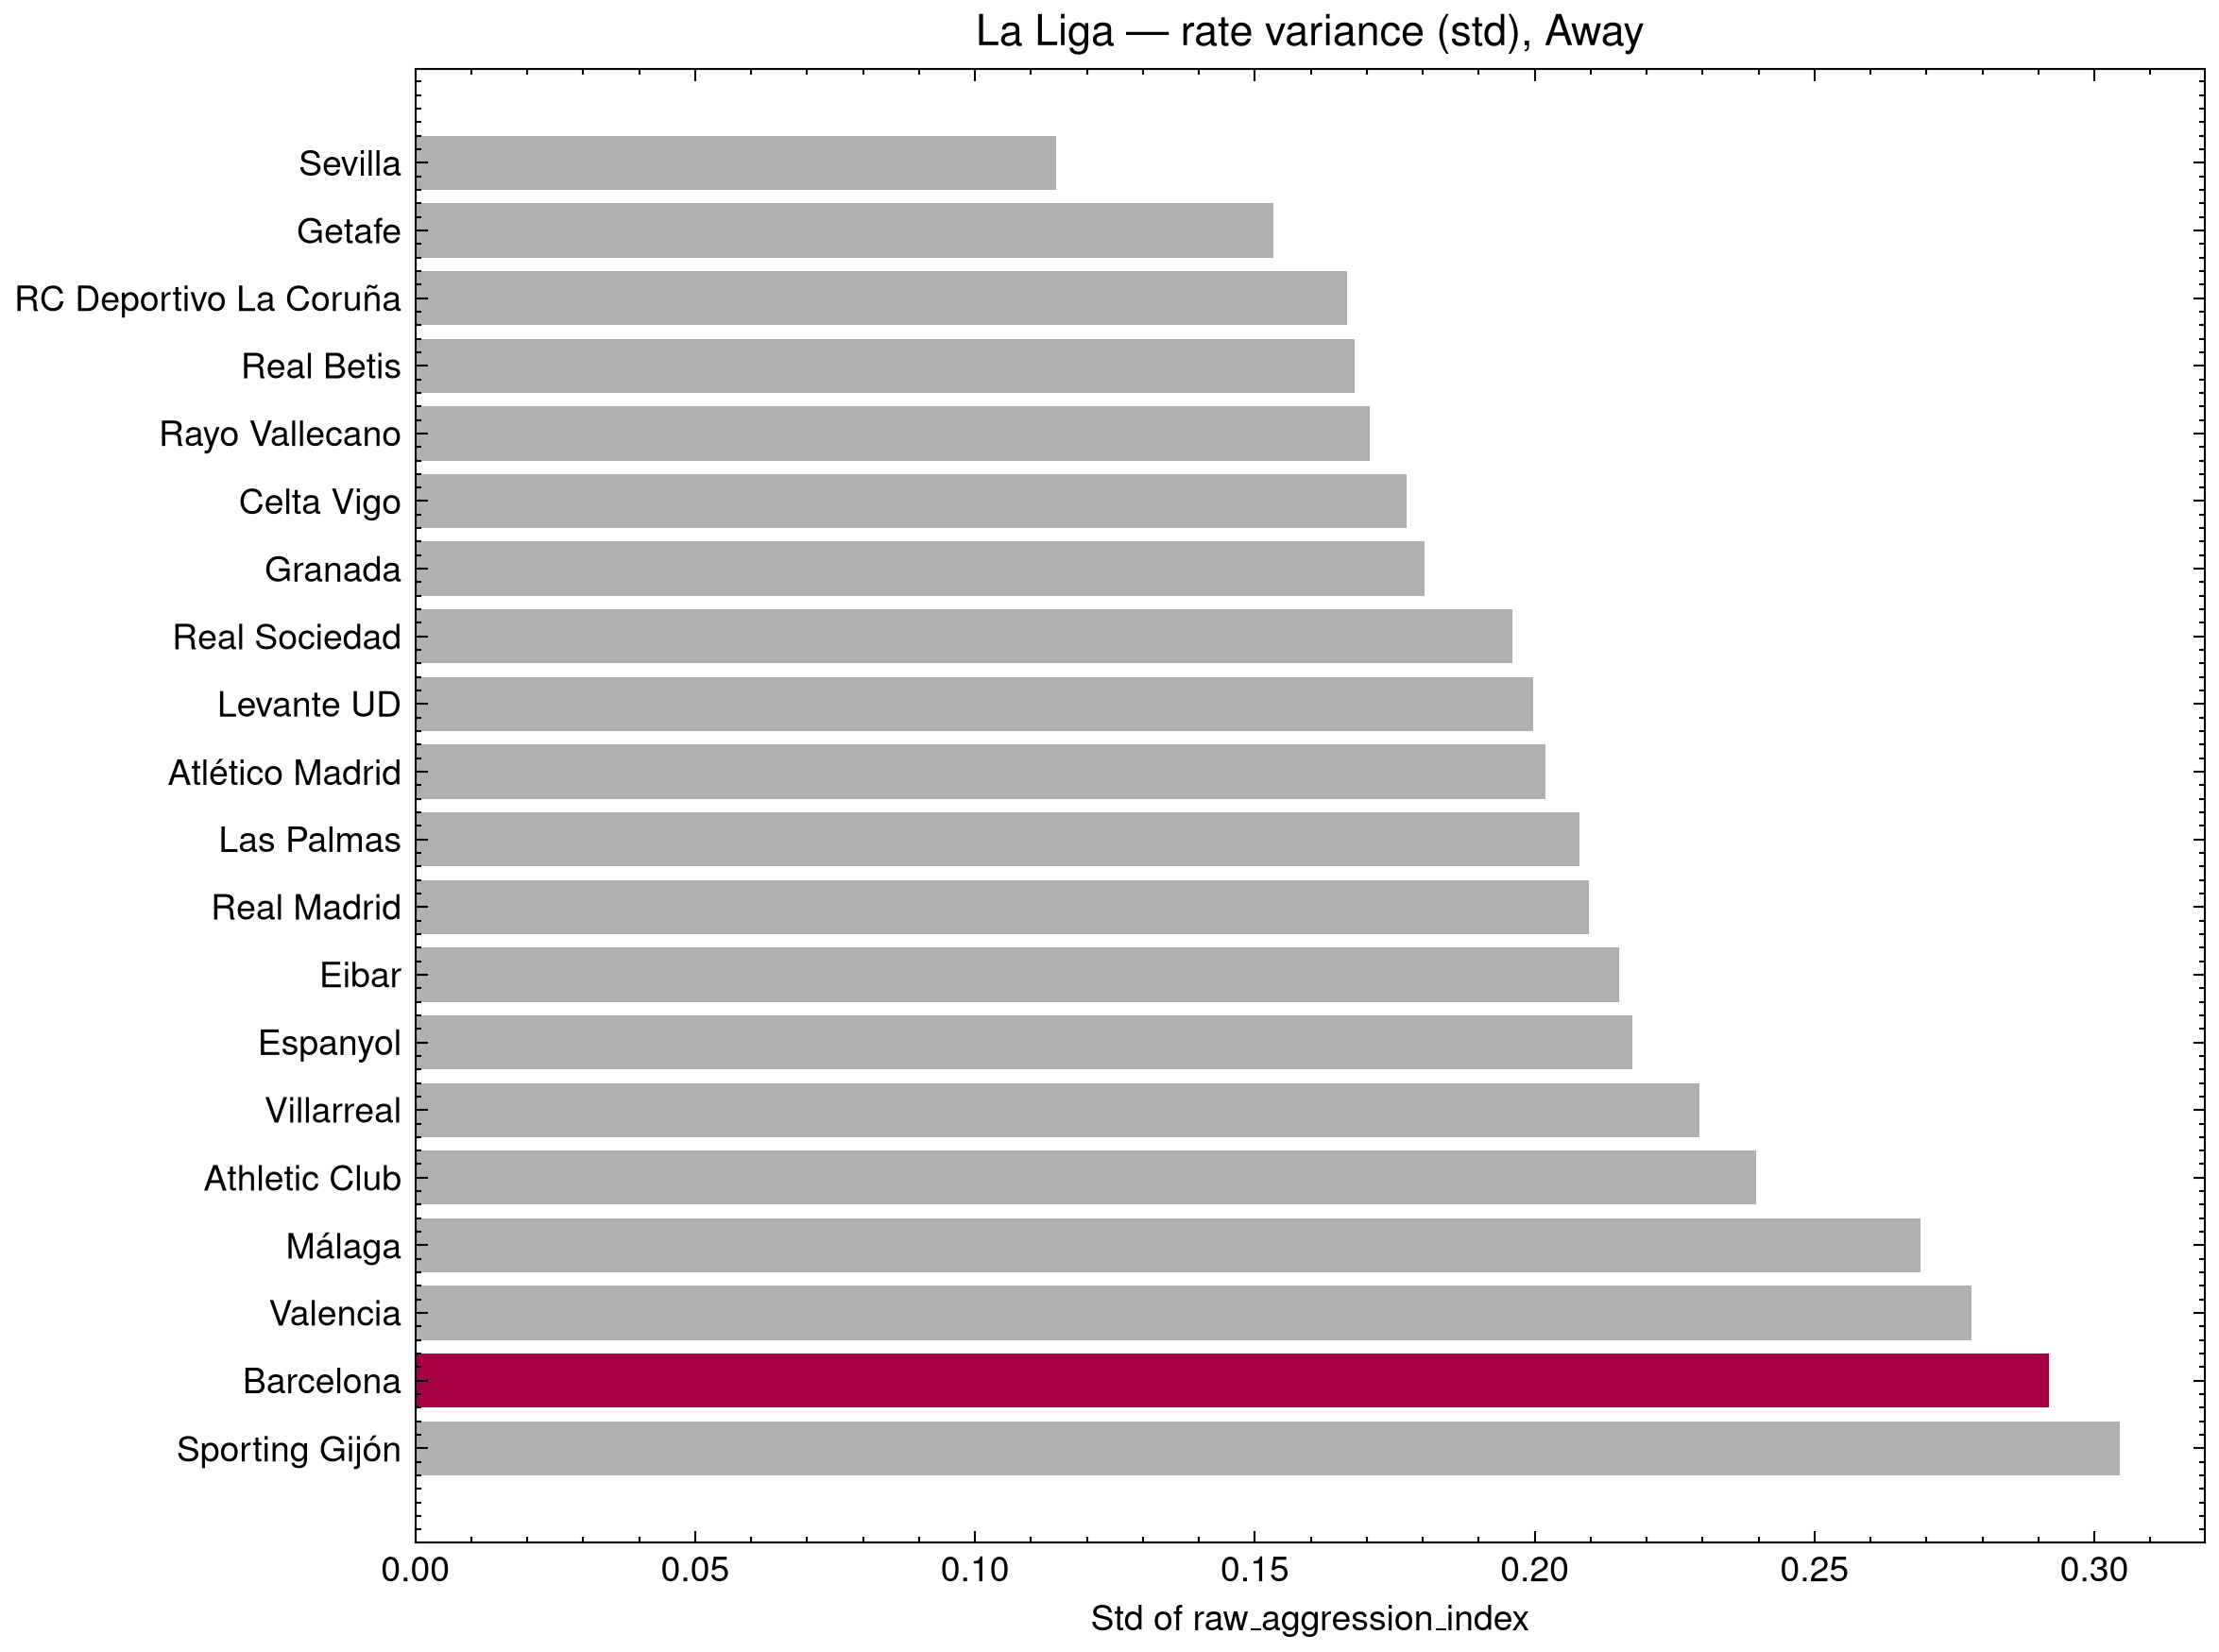

In [34]:
plot_ranked_bar(
    away_summary["std_rate"].sort_values(),
    "La Liga — rate variance (std), Away",
    "Std of raw_aggression_index",
)

# Is the extra away variance a smooth spread or a few outliers

Sorting Barcelona's 19 away matches by rate and flagging anything more than 1.5 standard deviations from the mean.

In [35]:
barca_away_matches = la_liga_diagnostics_df[
    (la_liga_diagnostics_df["team"] == "Barcelona") & (la_liga_diagnostics_df["venue"] == "Away")
].copy()

barca_away_mean = barca_away_matches["rate"].mean()
barca_away_std = barca_away_matches["rate"].std()
barca_away_matches["z"] = (barca_away_matches["rate"] - barca_away_mean) / barca_away_std

barca_away_matches.sort_values("rate")[["opponent", "attempts", "opponent_possessions", "rate", "z"]]

,opponent,attempts,opponent_possessions,rate,z
739,Eibar,43,108,0.398148,-1.628637
613,Sevilla,52,105,0.495238,-1.296034
731,Villarreal,43,77,0.558442,-1.079517
717,Athletic Club,42,74,0.567568,-1.048253
749,Real Madrid,60,100,0.600000,-0.937149
745,Levante UD,60,87,0.689655,-0.630016
709,Málaga,57,81,0.703704,-0.581889
725,Sporting Gijón,61,72,0.847222,-0.090235
743,Atlético Madrid,61,72,0.847222,-0.090235
727,Granada,72,79,0.911392,0.129594


In [36]:
outlier_removed_std = barca_away_matches.loc[barca_away_matches["opponent"] != "Real Betis", "rate"].std()

print("Std with Real Betis:", round(barca_away_std, 3))
print("Std without Real Betis:", round(outlier_removed_std, 3))
print("League average away std (excl. Barcelona):", round(league_avg_away["std_rate"], 3))

Std with Real Betis: 0.292
Std without Real Betis: 0.241
League average away std (excl. Barcelona): 0.205


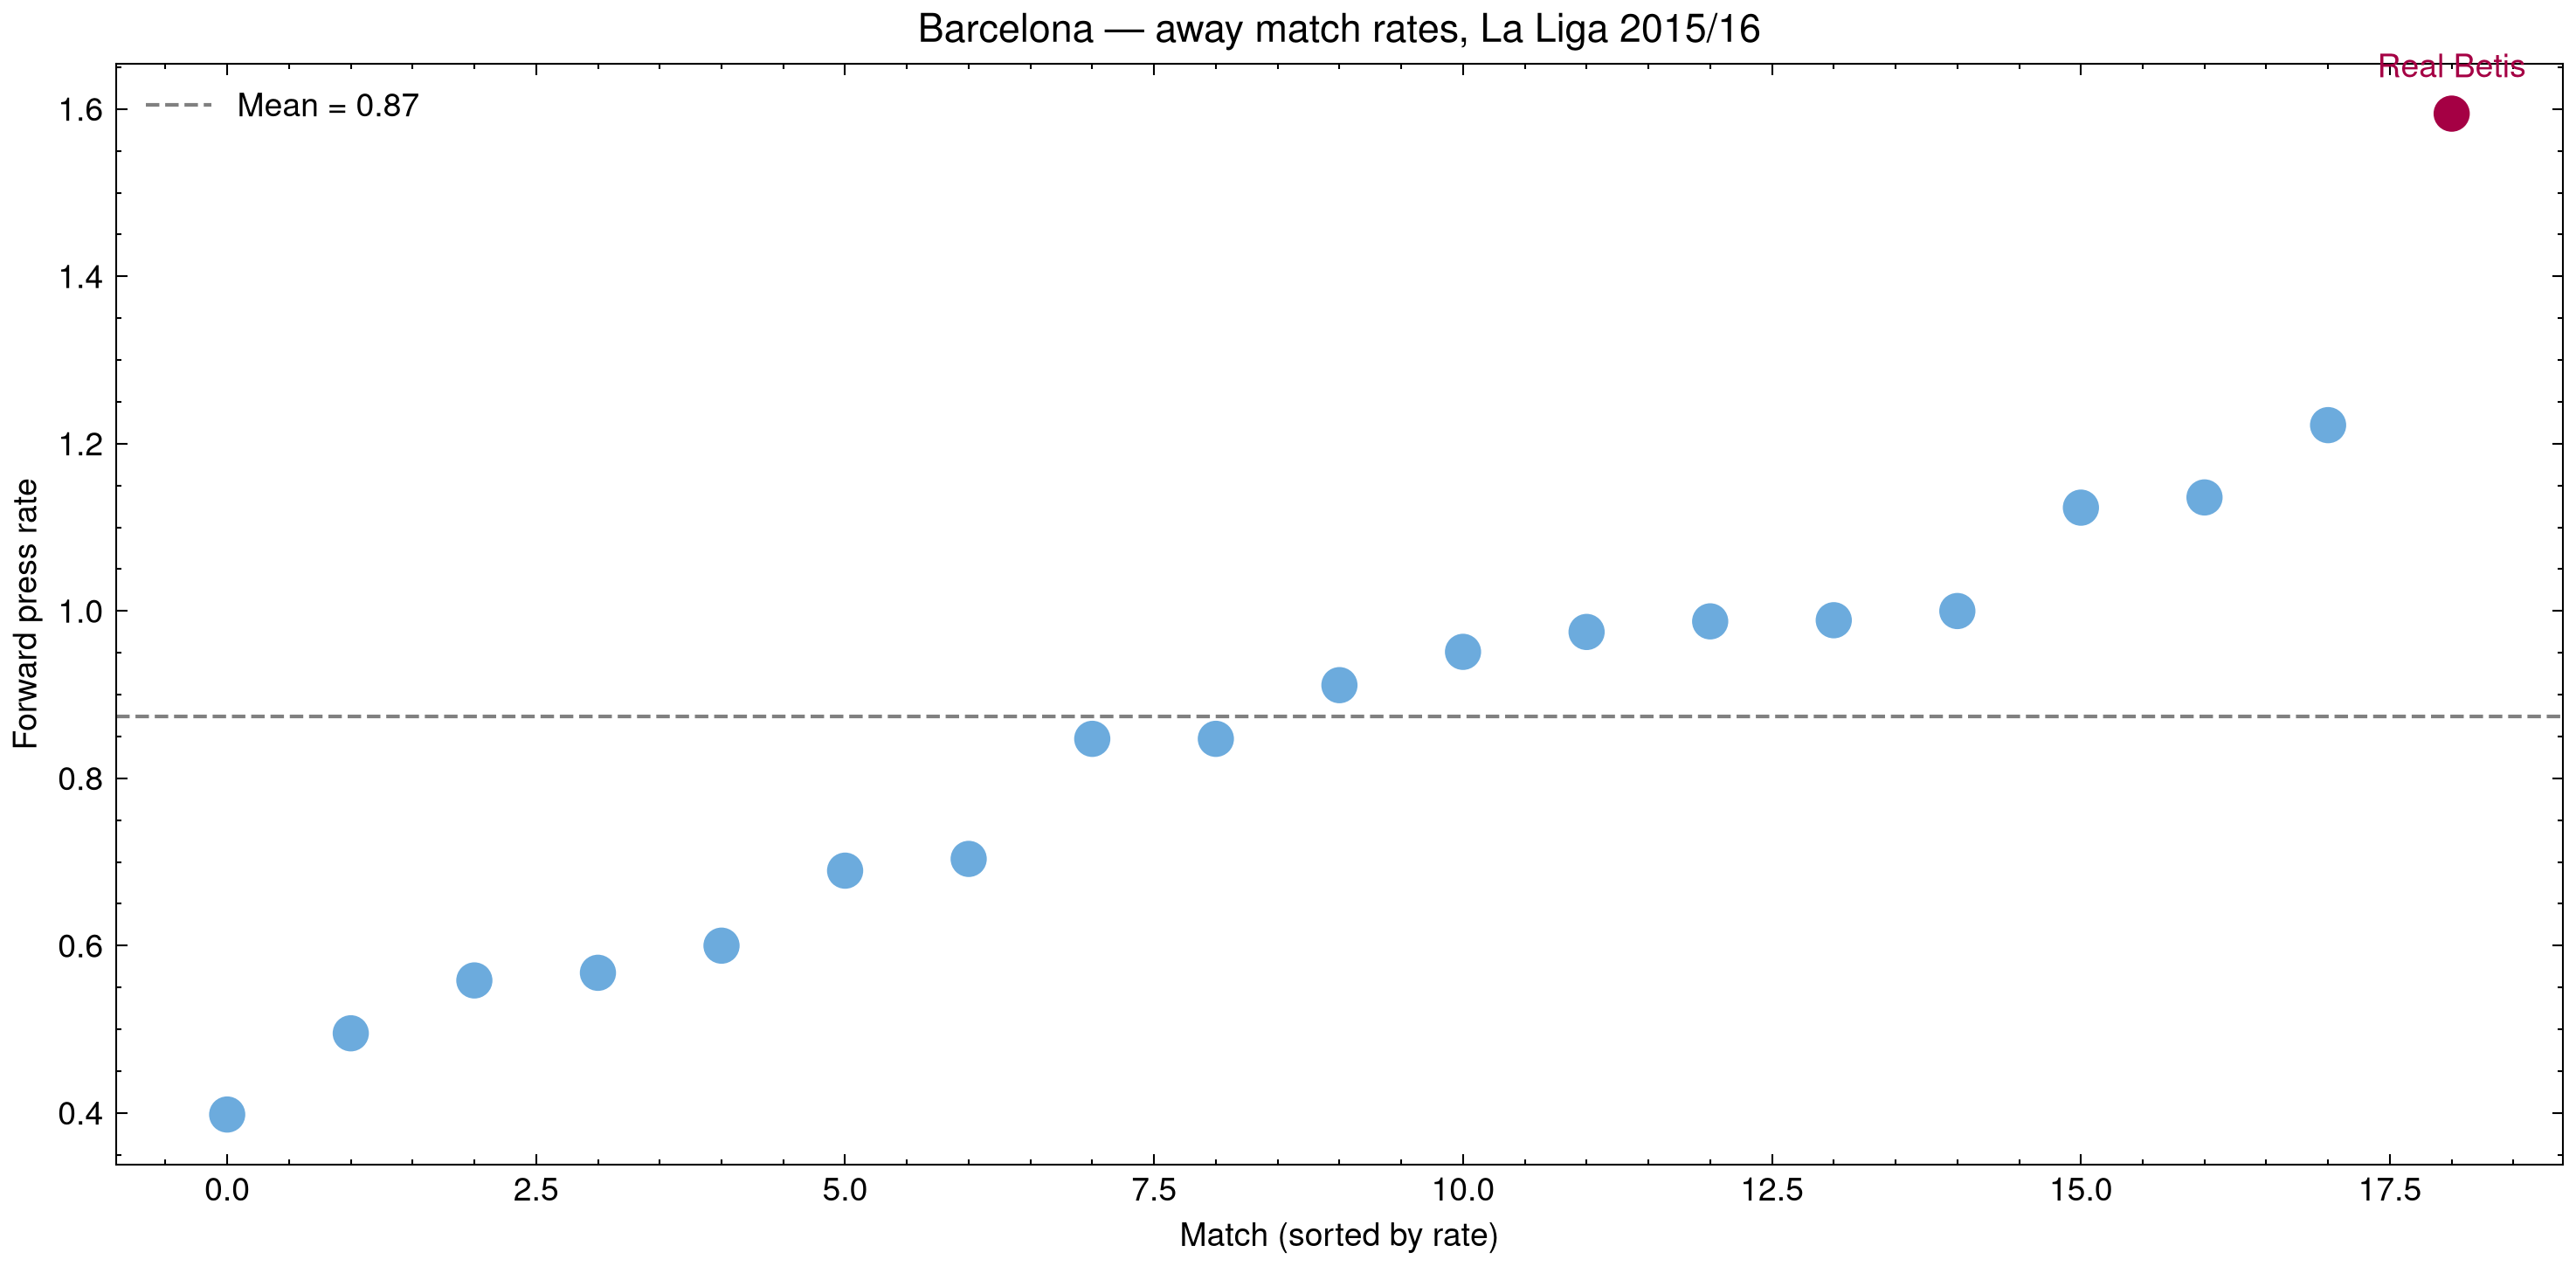

In [37]:
barca_away_sorted = barca_away_matches.sort_values("rate").reset_index(drop=True)
point_colors = ["#A50044" if opp == "Real Betis" else "#6CABDD" for opp in barca_away_sorted["opponent"]]

plt.figure(figsize=(10, 5))
plt.scatter(range(len(barca_away_sorted)), barca_away_sorted["rate"], color=point_colors, s=80, zorder=3)
plt.axhline(barca_away_mean, color="grey", linestyle="--", label=f"Mean = {barca_away_mean:.2f}")

betis_idx = barca_away_sorted.index[barca_away_sorted["opponent"] == "Real Betis"][0]
plt.annotate(
    "Real Betis", (betis_idx, barca_away_sorted.loc[betis_idx, "rate"]),
    textcoords="offset points", xytext=(0, 10), ha="center", color="#A50044", fontweight="bold",
)

plt.xlabel("Match (sorted by rate)")
plt.ylabel("Forward press rate")
plt.title("Barcelona — away match rates, La Liga 2015/16")
plt.legend()
plt.tight_layout()
plt.show()

# Takeaways

Barcelona's rank is not a bug — both the raw numbers and the mechanism behind them check out. Two things are happening at once: Barcelona genuinely generates fewer pressing attempt-events per opponent possession than teams like Eibar or Atlético Madrid (a real behavioral difference the score is correctly detecting, not something normalization should or does erase), and Barcelona's unusually small, long-possession-dominated matches make its per-match rate noisier than most teams' — explaining most of the elevated home variance and roughly half of the away variance, with a single extreme match (away at Real Betis) accounting for most of the rest. None of this invalidates the metric; it's a useful illustration of why n=19 matches per venue makes any single team's variance ellipse noisy enough that it shouldn't be over-interpreted from one season alone.

# Testing the pressing-efficiency hypothesis

A sharper version of hypothesis 1 above: two teams could apply the same territorial strategy — contesting the ball in the opponent's half — and still end up with very different `raw_aggression_index` values if one needs far fewer attempts than the other to actually win the ball back. This tests that directly: what fraction of opponent-half `Tackle` and `Interception` attempts actually succeed, for Barcelona vs. two teams that outranked it — Eibar (La Liga) and Bournemouth (Premier League, the team that topped the very first version of this ranking). `Pressure` is excluded here because it carries no explicit success/failure outcome in the data, and `Foul Committed` isn't really a ball-winning attempt in the same sense — so this only tests the subset of the numerator with a clean outcome label.

In [38]:
SUCCESS_DUEL_OUTCOMES = {"Won", "Success", "Success In Play"}
SUCCESS_INTERCEPTION_OUTCOMES = {"Won", "Success", "Success In Play", "Success Out"}


def compute_efficiency_for_team(competition_id, season_id, team):
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    team_matches = matches[(matches.home_team == team) | (matches.away_team == team)]

    tackle_attempts = tackle_successes = 0
    intercept_attempts = intercept_successes = 0

    for _, m in team_matches.iterrows():
        events = sb.events(match_id=m["match_id"])
        loc_x = _loc_x(events)
        own_zone = (events["team"] == team) & loc_x.notna() & (loc_x > 60)

        tackles = events[own_zone & (events["type"] == "Duel") & (events["duel_type"] == "Tackle")]
        intercepts = events[own_zone & (events["type"] == "Interception")]

        tackle_attempts += len(tackles)
        tackle_successes += tackles["duel_outcome"].isin(SUCCESS_DUEL_OUTCOMES).sum()

        intercept_attempts += len(intercepts)
        intercept_successes += intercepts["interception_outcome"].isin(SUCCESS_INTERCEPTION_OUTCOMES).sum()

    total_attempts = tackle_attempts + intercept_attempts
    total_successes = tackle_successes + intercept_successes

    return {
        "team": team,
        "tackle_attempts": tackle_attempts, "tackle_successes": tackle_successes,
        "tackle_success_rate": tackle_successes / tackle_attempts if tackle_attempts else np.nan,
        "intercept_attempts": intercept_attempts, "intercept_successes": intercept_successes,
        "intercept_success_rate": intercept_successes / intercept_attempts if intercept_attempts else np.nan,
        "overall_attempts": total_attempts, "overall_successes": total_successes,
        "overall_success_rate": total_successes / total_attempts if total_attempts else np.nan,
    }


efficiency_path = "data/pressing_efficiency_check.csv"

if os.path.exists(efficiency_path):
    efficiency_df = pd.read_csv(efficiency_path)
else:
    efficiency_rows = [
        compute_efficiency_for_team(11, 27, "Barcelona"),
        compute_efficiency_for_team(11, 27, "Eibar"),
        compute_efficiency_for_team(2, 27, "AFC Bournemouth"),
    ]
    efficiency_df = pd.DataFrame(efficiency_rows)
    efficiency_df.to_csv(efficiency_path, index=False)

efficiency_df

,team,tackle_attempts,tackle_successes,tackle_success_rate,intercept_attempts,intercept_successes,intercept_success_rate,overall_attempts,overall_successes,overall_success_rate
0,Barcelona,222,134,0.603604,128,75,0.585938,350,209,0.597143
1,Eibar,270,156,0.577778,172,116,0.674419,442,272,0.615385
2,AFC Bournemouth,221,118,0.533937,88,57,0.647727,309,175,0.566343


The hypothesis doesn't hold up cleanly. Eibar (61.5% overall success) is not less efficient than Barcelona (59.7%) — if anything, slightly more, while also attempting far more (442 vs. 350 across the season). That directly cuts against "Eibar just needs more tries for the same result." Bournemouth does show a gap in the expected direction (56.6%), but it's a modest few points, not a dramatic one. Reported here as-is: the analysis doesn't always confirm the hypothesis that motivated it, and that's worth showing plainly rather than reaching for a version of the test that would.

# Extending efficiency to Pressure events

`Pressure` was excluded from the efficiency check above because it has no direct success/failure outcome field. StatsBomb does link a `Pressure` event to the action it pressured via `related_events`, though — mostly the pressured player's `Carry` and `Pass`. Focusing on the pressures linked to a `Pass`: did that pass fail (`pass_outcome` not null) right after being pressured? Coverage is partial (roughly 40-48% of pressures link to a pass at all — the rest link only to a `Carry` or nothing, which carries no direct success/failure signal), so this measures a subset of pressures, not all of them.

In [39]:
def compute_pressure_effectiveness_for_team(competition_id, season_id, team):
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    team_matches = matches[(matches.home_team == team) | (matches.away_team == team)]

    total_pressures = 0
    pressures_with_linked_pass = 0
    passes_failed = 0

    for _, m in team_matches.iterrows():
        events = sb.events(match_id=m["match_id"])
        events_by_id = events.set_index("id")
        loc_x = _loc_x(events)
        own_zone_pressures = events[
            (events["team"] == team) & (events["type"] == "Pressure")
            & loc_x.notna() & (loc_x > 60)
        ]

        total_pressures += len(own_zone_pressures)
        for _, p in own_zone_pressures.iterrows():
            related = p["related_events"]
            if not isinstance(related, list):
                continue
            linked_passes = [
                rid for rid in related
                if rid in events_by_id.index and events_by_id.loc[rid, "type"] == "Pass"
            ]
            if not linked_passes:
                continue
            pressures_with_linked_pass += 1
            outcomes = [events_by_id.loc[rid, "pass_outcome"] for rid in linked_passes]
            if any(pd.notna(o) for o in outcomes):
                passes_failed += 1

    return {
        "team": team,
        "total_pressures": total_pressures,
        "pressures_with_linked_pass": pressures_with_linked_pass,
        "coverage": pressures_with_linked_pass / total_pressures if total_pressures else np.nan,
        "passes_failed": passes_failed,
        "pressure_disruption_rate": passes_failed / pressures_with_linked_pass if pressures_with_linked_pass else np.nan,
    }


pressure_effectiveness_path = "data/pressure_effectiveness_check.csv"

if os.path.exists(pressure_effectiveness_path):
    pressure_effectiveness_df = pd.read_csv(pressure_effectiveness_path)
else:
    pressure_effectiveness_rows = [
        compute_pressure_effectiveness_for_team(11, 27, "Barcelona"),
        compute_pressure_effectiveness_for_team(11, 27, "Eibar"),
        compute_pressure_effectiveness_for_team(2, 27, "AFC Bournemouth"),
    ]
    pressure_effectiveness_df = pd.DataFrame(pressure_effectiveness_rows)
    pressure_effectiveness_df.to_csv(pressure_effectiveness_path, index=False)

pressure_effectiveness_df

,team,total_pressures,pressures_with_linked_pass,coverage,passes_failed,pressure_disruption_rate
0,Barcelona,2290,895,0.390830,246,0.274860
1,Eibar,2988,1286,0.430388,393,0.305599
2,AFC Bournemouth,2778,1343,0.483441,416,0.309754


This closes the gap the earlier tackle/interception check couldn't reach, and the efficiency hypothesis fails here too — more clearly than before. Barcelona's pressure disruption rate (27.5%) is the **lowest** of the three, not the highest: both Eibar (30.6%) and Bournemouth (31.0%) force an incomplete pass more often per pressure than Barcelona does. Combined with the tackle/interception result, neither measure of per-attempt quality is higher for Barcelona than for the teams that outranked it. What does hold up from the earlier investigation is the volume story: Barcelona simply faces fewer opponent possessions to press against (the smaller-denominator finding), not that each individual attempt is more clinical.

# Combined defensive-action efficiency

Pooling `Tackle`, `Interception`, and pressure-with-linked-pass into a single efficiency number per team, reusing the two tables already computed above — no new fetching needed. `Foul Committed` and pressures with no linked pass are still excluded, since neither has a natural success/failure signal to pool in.

In [40]:
combined_efficiency_df = efficiency_df.merge(pressure_effectiveness_df, on="team")
combined_efficiency_df["combined_attempts"] = (
    combined_efficiency_df["overall_attempts"] + combined_efficiency_df["pressures_with_linked_pass"]
)
combined_efficiency_df["combined_successes"] = (
    combined_efficiency_df["overall_successes"] + combined_efficiency_df["passes_failed"]
)
combined_efficiency_df["combined_efficiency_rate"] = (
    combined_efficiency_df["combined_successes"] / combined_efficiency_df["combined_attempts"]
)

combined_efficiency_df[["team", "combined_attempts", "combined_successes", "combined_efficiency_rate"]]

,team,combined_attempts,combined_successes,combined_efficiency_rate
0,Barcelona,1245,455,0.365462
1,Eibar,1728,665,0.384838
2,AFC Bournemouth,1652,591,0.357748


Pooling everything changes the picture slightly: Barcelona (36.5%) now edges out Bournemouth (35.8%), but Eibar (38.5%) remains clearly the most efficient of the three even combined across all defensive-action types. The core finding stands: nothing here supports Barcelona being more efficient than the teams that outranked it — at best it's roughly tied with one of them, and still behind the other.

# Illustrating recoveries on the pitch

One match per team — Barcelona, Eibar, Bournemouth — plotting every defensive-action attempt in the opponent's half as a dot on the pitch: `Tackle`, `Interception`, and pressure-with-linked-pass, colored by whether it succeeded. The illustrative match for each team is the one with the most such attempts (combined across all three types) in their season, so the plot has enough points to be legible rather than being cherry-picked for a favorable result.

In [41]:
def classify_pressure_attempts(events, team):
    events_by_id = events.set_index("id")
    loc_x = _loc_x(events)
    own_zone_pressures = events[
        (events["team"] == team) & (events["type"] == "Pressure") & loc_x.notna() & (loc_x > 60)
    ].copy()

    def pass_failed(related):
        if not isinstance(related, list):
            return np.nan
        linked_passes = [
            rid for rid in related
            if rid in events_by_id.index and events_by_id.loc[rid, "type"] == "Pass"
        ]
        if not linked_passes:
            return np.nan
        outcomes = [events_by_id.loc[rid, "pass_outcome"] for rid in linked_passes]
        return any(pd.notna(o) for o in outcomes)

    own_zone_pressures["success"] = own_zone_pressures["related_events"].apply(pass_failed)
    return own_zone_pressures.dropna(subset=["success"])


def pick_busiest_match(competition_id, season_id, team, exclude_opponents=None):
    exclude_opponents = exclude_opponents or []
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    team_matches = matches[(matches.home_team == team) | (matches.away_team == team)]

    best_match_id, best_count = None, -1
    for _, m in team_matches.iterrows():
        opponent = m["away_team"] if m["home_team"] == team else m["home_team"]
        if opponent in exclude_opponents:
            continue
        events = sb.events(match_id=m["match_id"])
        loc_x = _loc_x(events)
        own_zone = (events["team"] == team) & loc_x.notna() & (loc_x > 60)
        tackle_intercept_count = (
            own_zone
            & (
                ((events["type"] == "Duel") & (events["duel_type"] == "Tackle"))
                | (events["type"] == "Interception")
            )
        ).sum()
        pressure_count = len(classify_pressure_attempts(events, team))
        count = tackle_intercept_count + pressure_count
        if count > best_count:
            best_match_id, best_count = m["match_id"], count
    return best_match_id, best_count

In [42]:
illustrative_matches_path = "data/illustrative_matches_combined.csv"

illustrative_teams = [
    ("Barcelona", 11, 27, []),
    ("Eibar", 11, 27, ["Barcelona"]),  # exclude Barcelona: it's a subject team itself, confusing as an opponent
    ("AFC Bournemouth", 2, 27, []),
]

if os.path.exists(illustrative_matches_path):
    illustrative_matches_df = pd.read_csv(illustrative_matches_path)
else:
    rows = []
    for team, competition_id, season_id, exclude_opponents in illustrative_teams:
        match_id, count = pick_busiest_match(competition_id, season_id, team, exclude_opponents)
        rows.append({"team": team, "match_id": match_id, "attempt_count": count})
    illustrative_matches_df = pd.DataFrame(rows)
    illustrative_matches_df.to_csv(illustrative_matches_path, index=False)

illustrative_matches_df

,team,match_id,attempt_count
0,Barcelona,3825627,71
1,Eibar,3825847,84
2,AFC Bournemouth,3754177,87


In [43]:
from mplsoccer import Pitch


def plot_recovery_attempts(match_id, team):
    events = sb.events(match_id=match_id)
    loc_x = _loc_x(events)
    own_zone = (events["team"] == team) & loc_x.notna() & (loc_x > 60)

    tackles = events[own_zone & (events["type"] == "Duel") & (events["duel_type"] == "Tackle")].copy()
    tackles["success"] = tackles["duel_outcome"].isin(SUCCESS_DUEL_OUTCOMES)

    intercepts = events[own_zone & (events["type"] == "Interception")].copy()
    intercepts["success"] = intercepts["interception_outcome"].isin(SUCCESS_INTERCEPTION_OUTCOMES)

    pressures = classify_pressure_attempts(events, team)

    attempts = pd.concat([tackles, intercepts, pressures])
    xs = attempts["location"].apply(lambda loc: loc[0])
    ys = attempts["location"].apply(lambda loc: loc[1])

    opponent = [t for t in events["team"].unique() if t != team][0]

    pitch = Pitch(pitch_type="statsbomb", pitch_color="#f8f8f8", line_color="#444444", half=True)
    fig, ax = pitch.draw(figsize=(8, 6))

    success_mask = attempts["success"].astype(bool)
    pitch.scatter(
        xs[success_mask], ys[success_mask], ax=ax,
        color="#2E8B57", alpha=0.65, edgecolors="black", linewidths=0.8,
        s=100, label="Won", zorder=3,
    )
    pitch.scatter(
        xs[~success_mask], ys[~success_mask], ax=ax,
        color="#C0392B", alpha=0.65, edgecolors="black", linewidths=0.8,
        s=100, label="Lost", zorder=3,
    )

    team_color = TEAM_COLORS.get(team, "#333333")
    ax.set_title(f"{team} vs. {opponent} — defensive-action attempts in opponent's half", color=team_color, fontsize=13)
    ax.legend(loc="upper left", fontsize=10)
    plt.show()

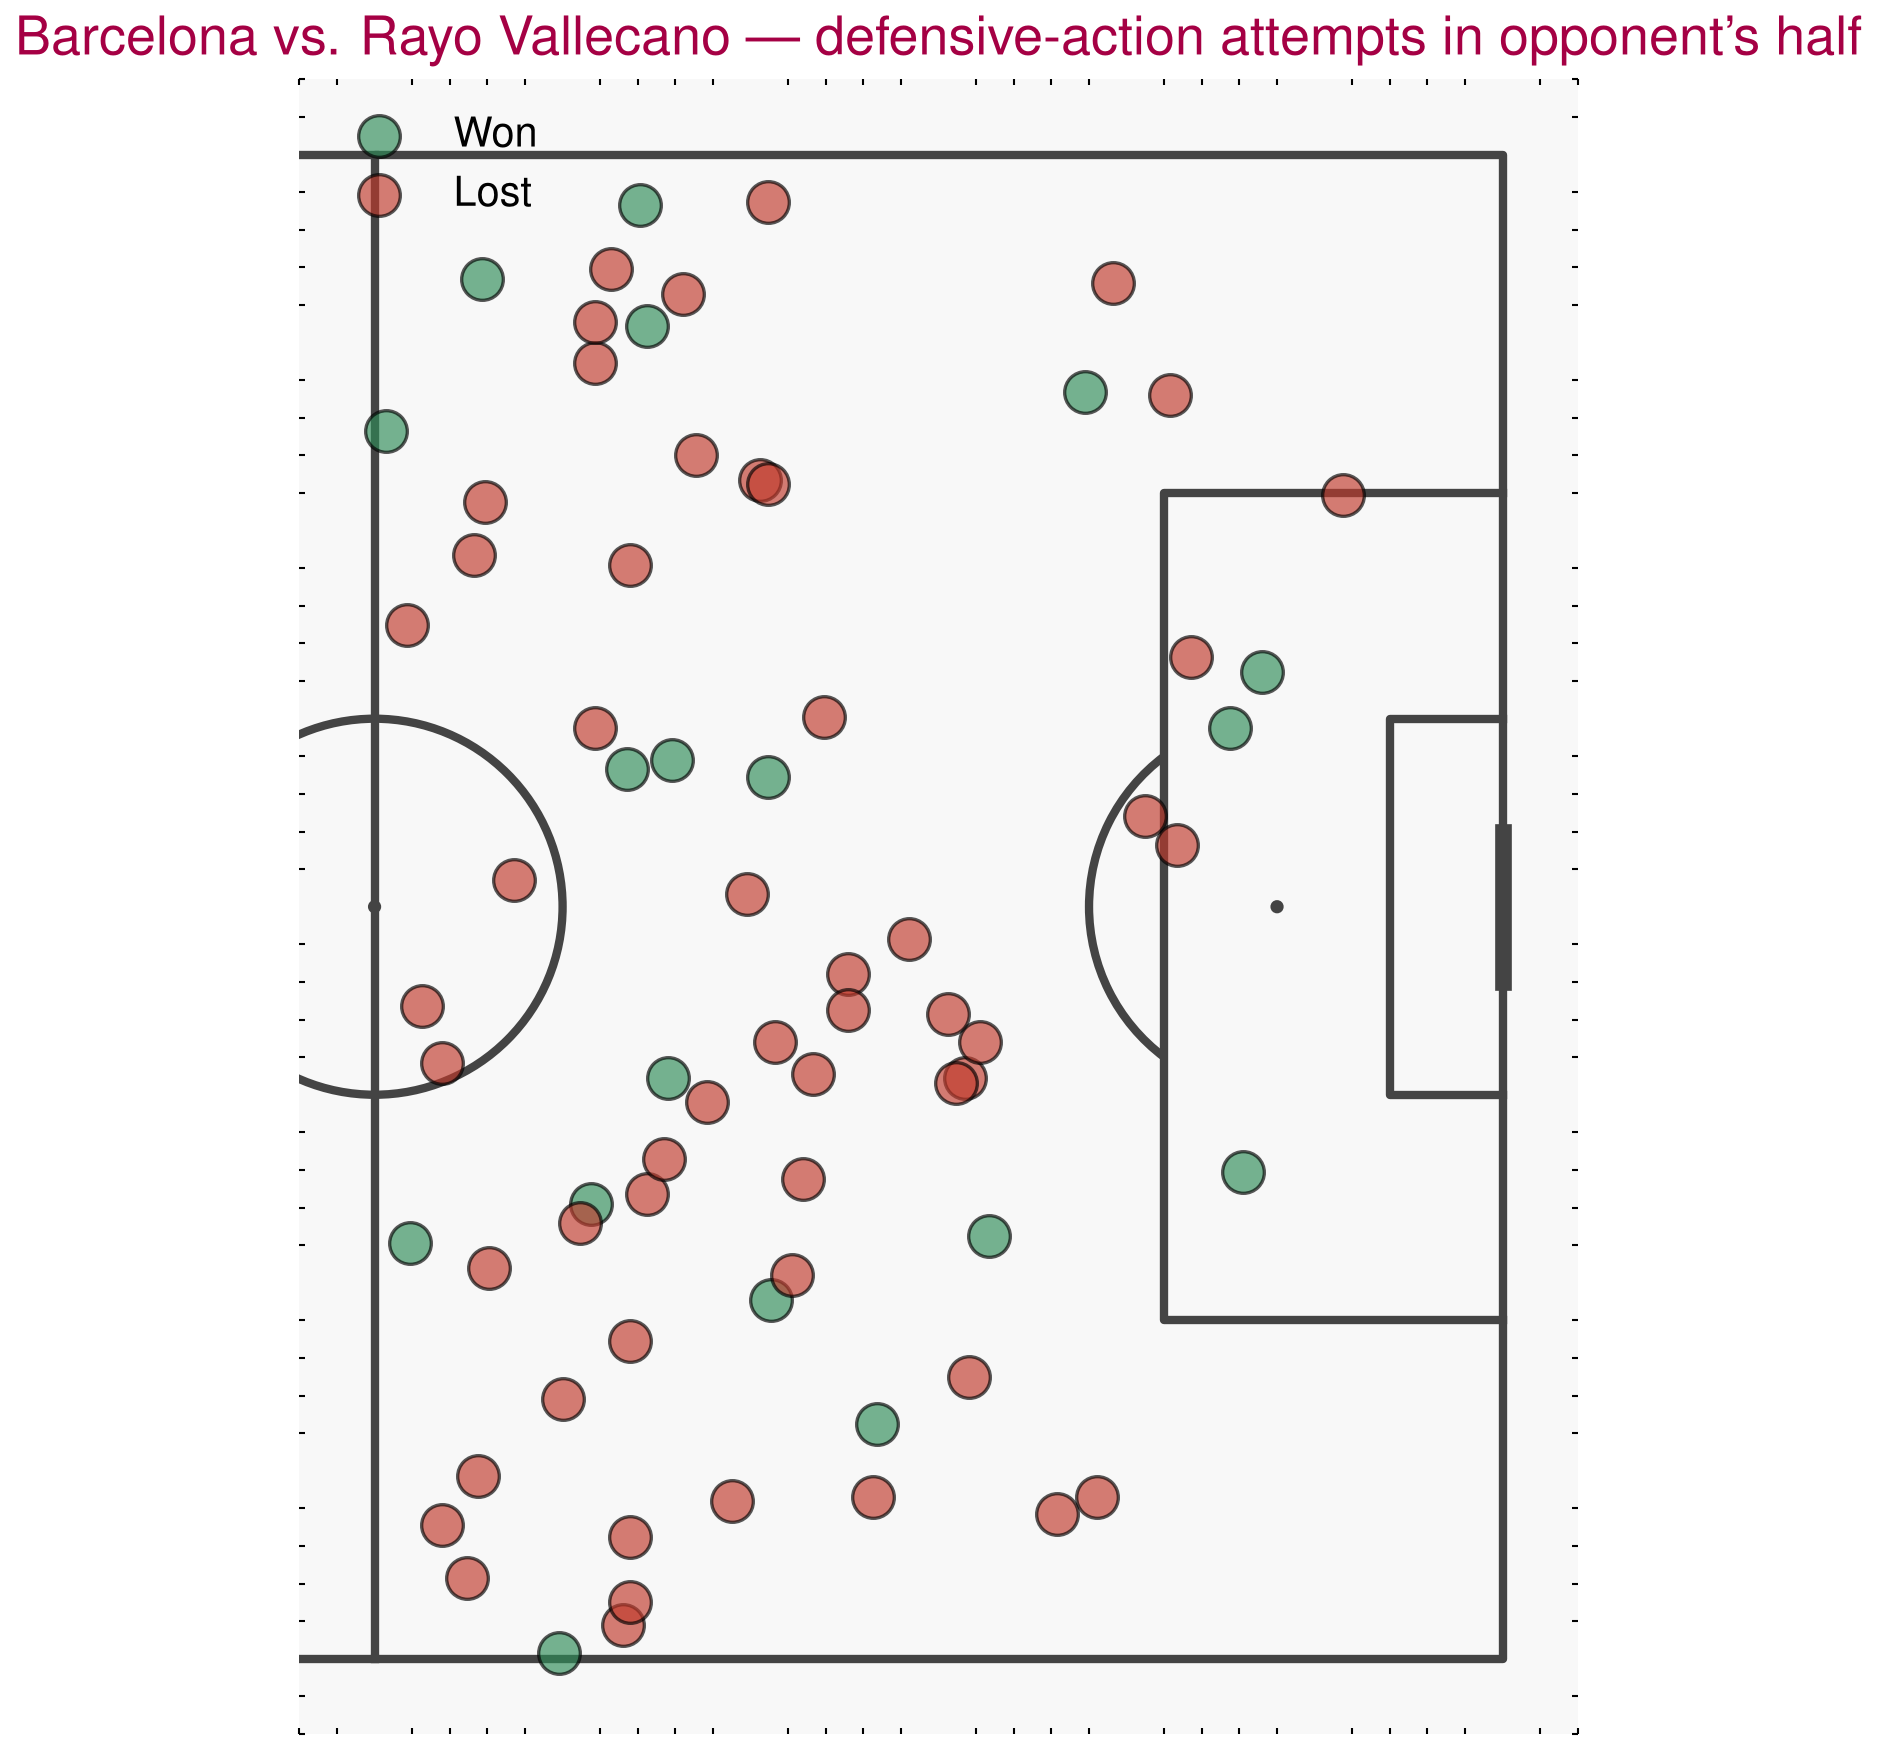

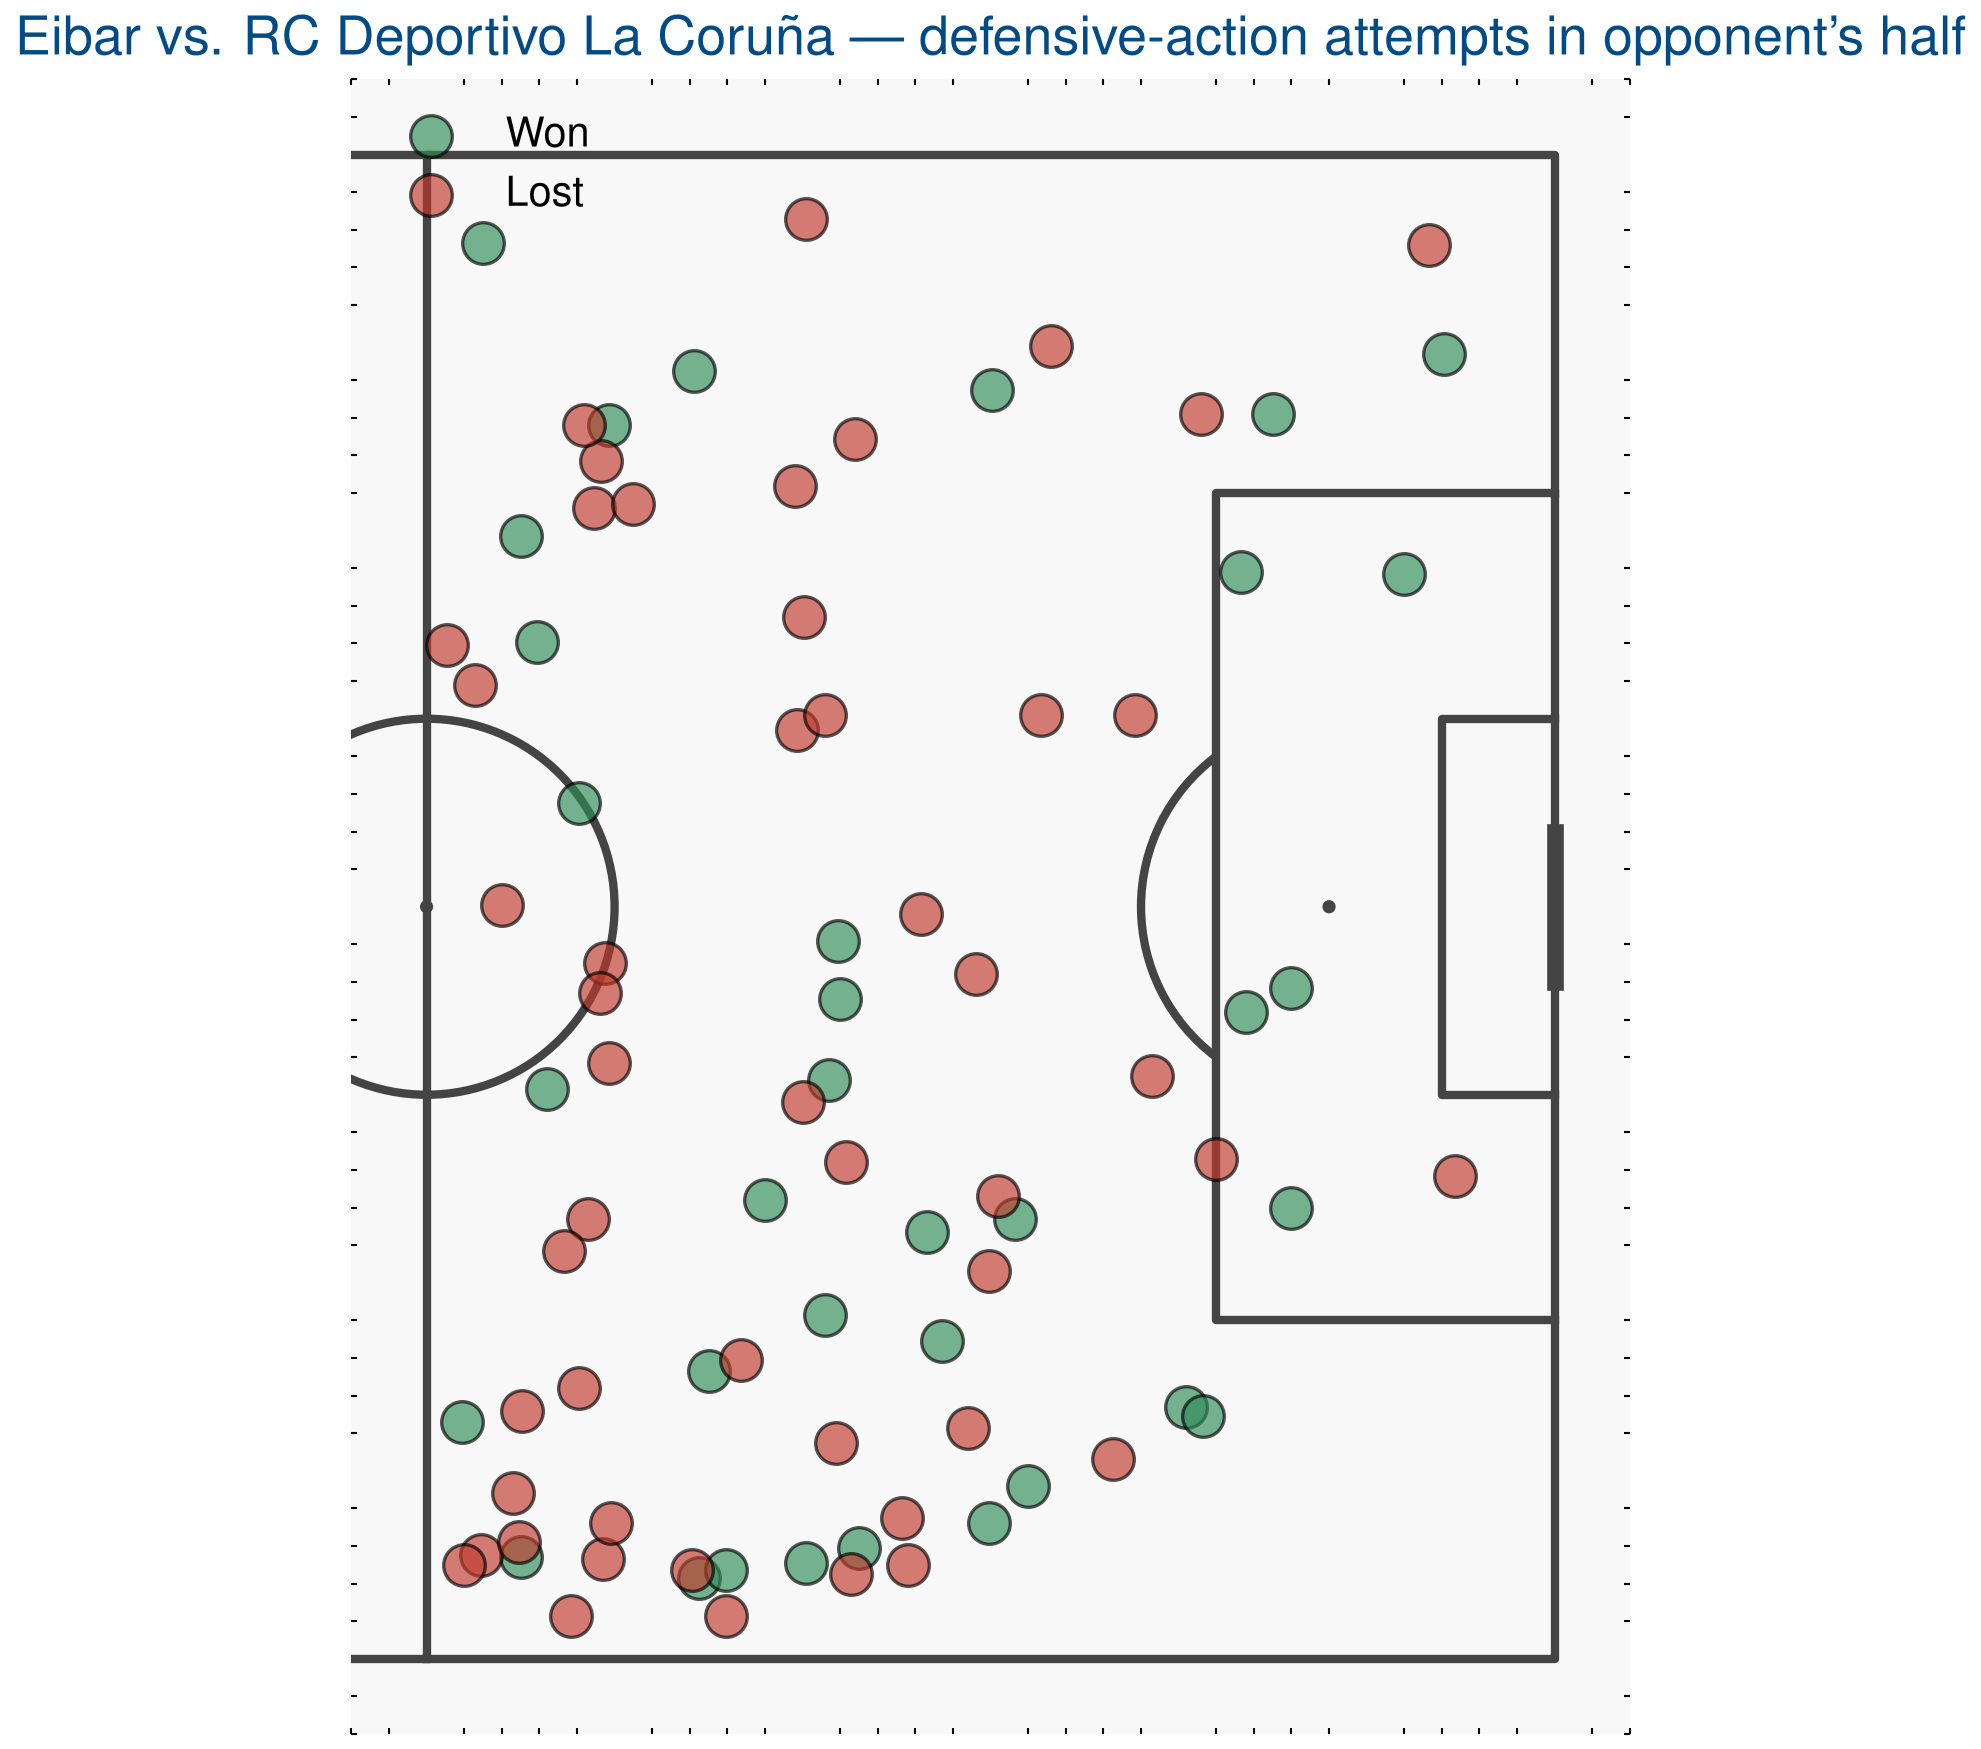

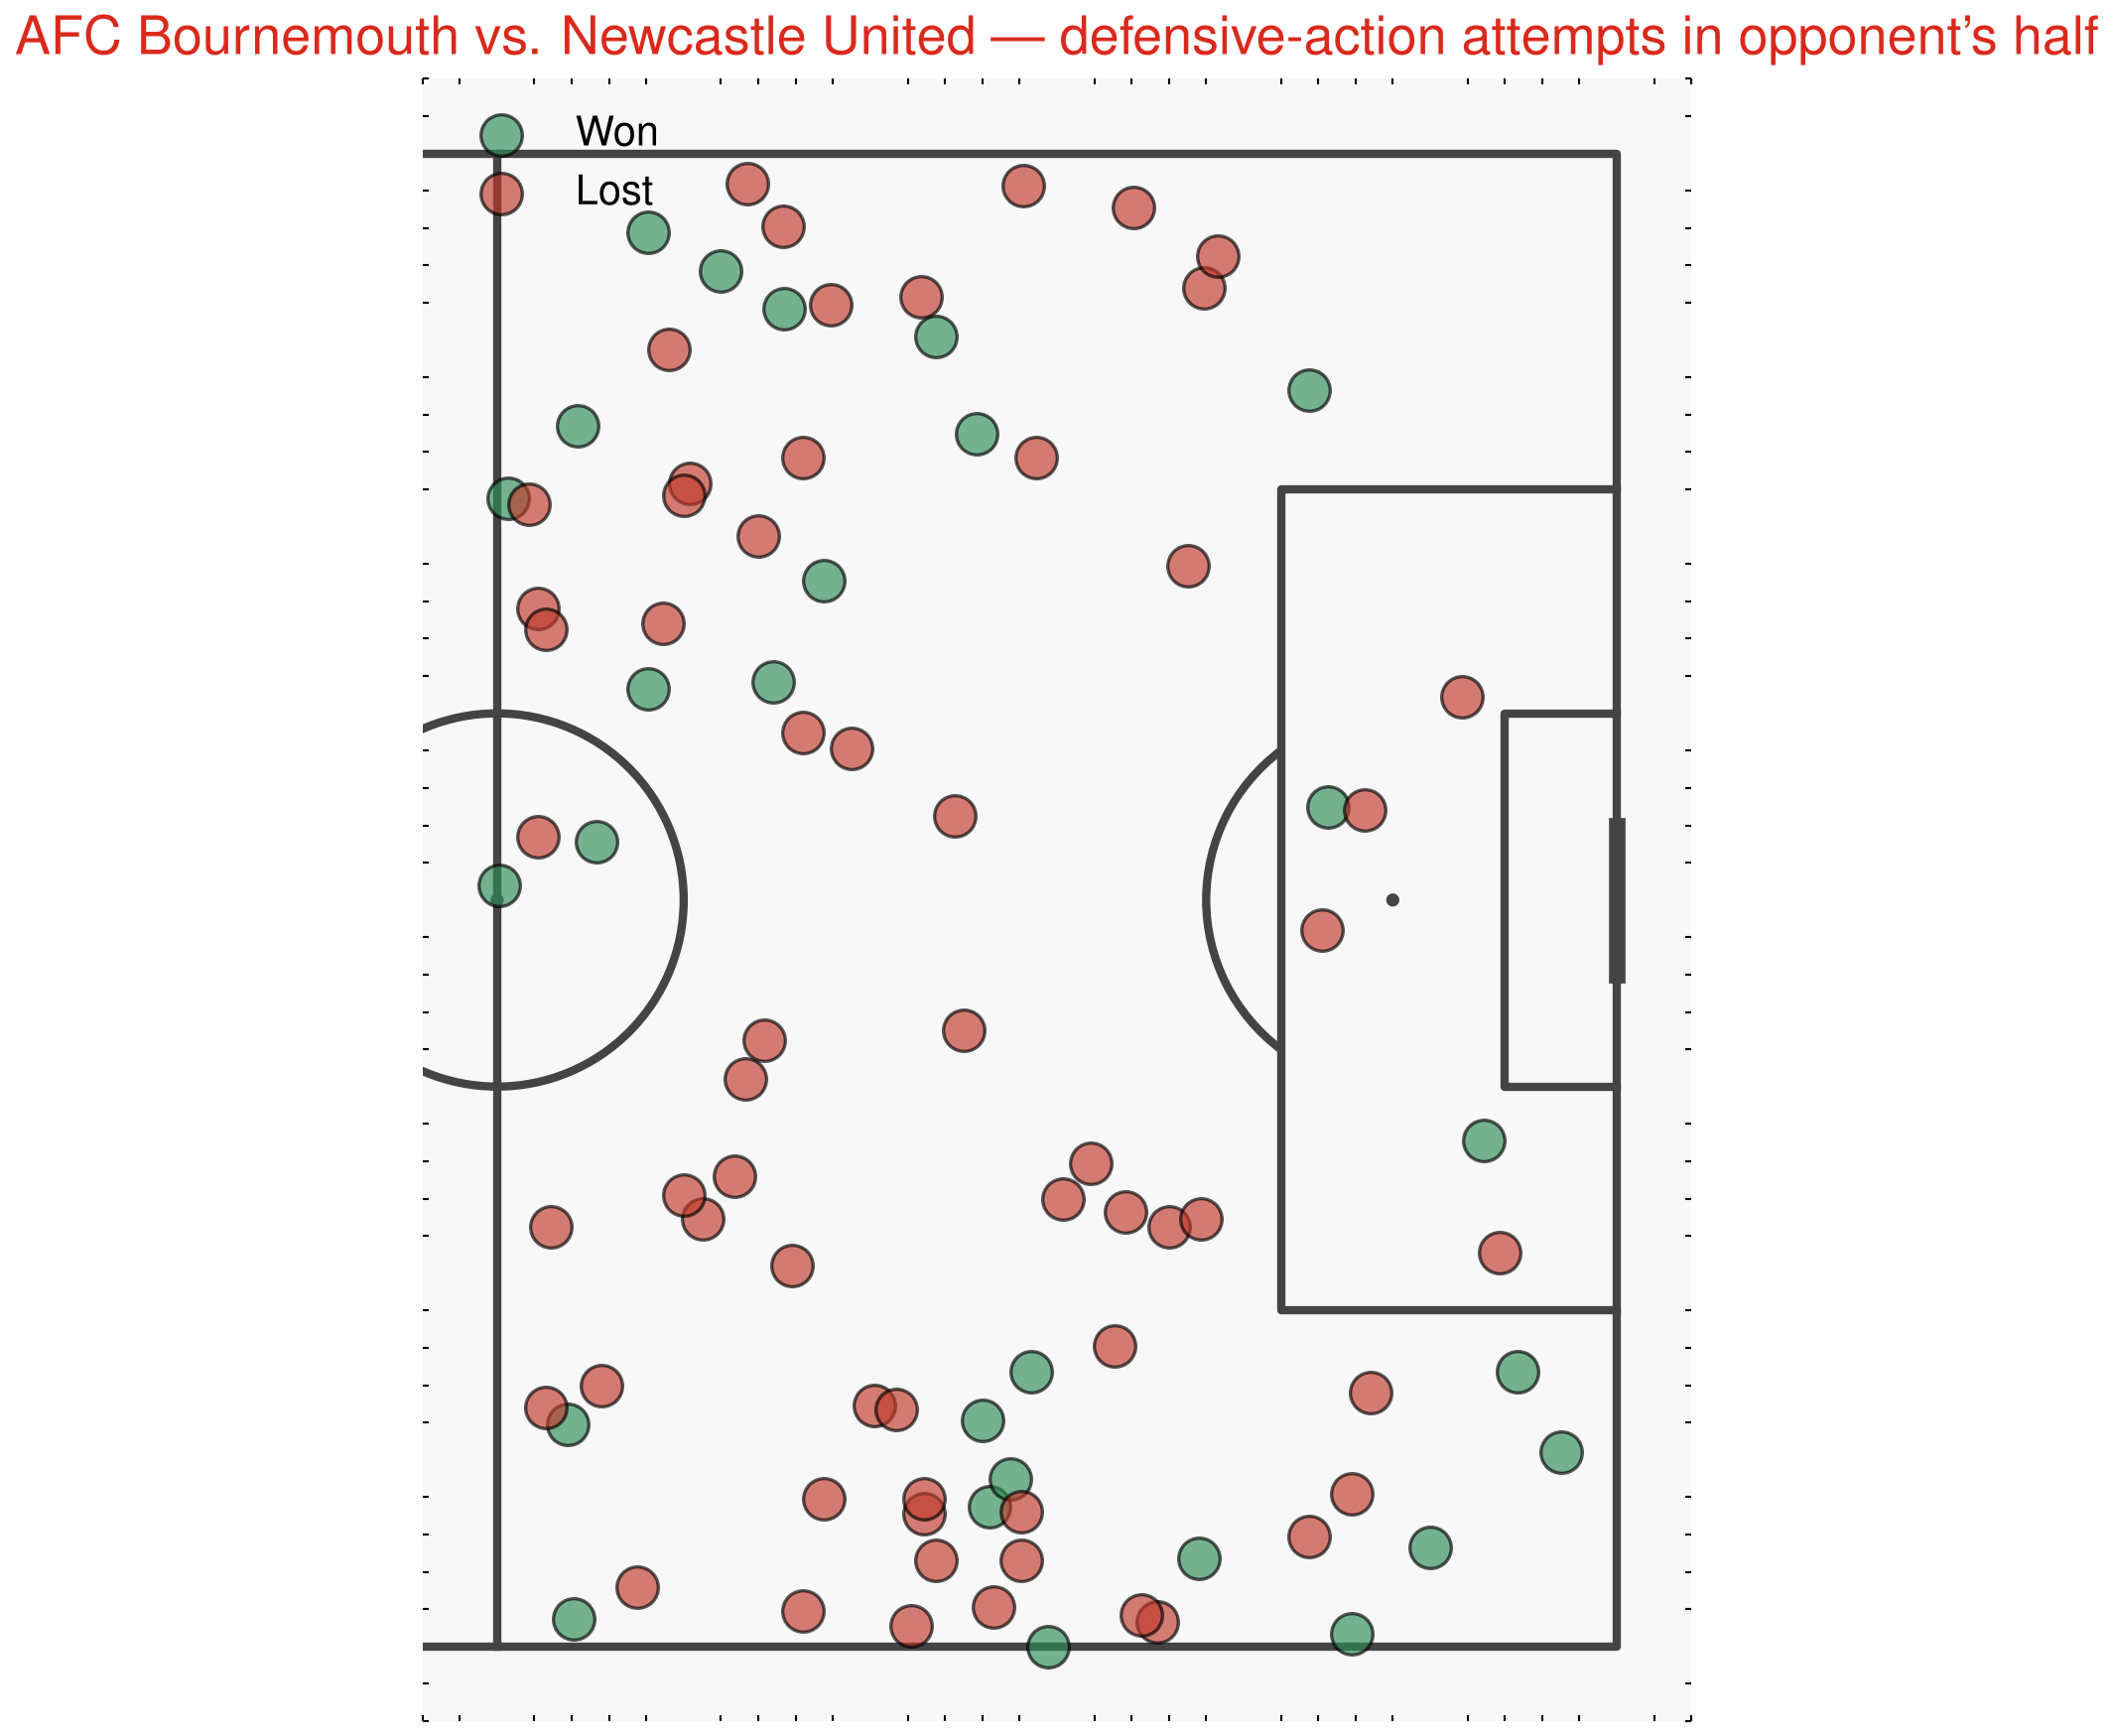

In [44]:
for _, row in illustrative_matches_df.iterrows():
    plot_recovery_attempts(row["match_id"], row["team"])

## Refining the raw score with control variables

Not implemented yet. To decide: how to use match state (first-half-only filtering), manager-spell identity, dead-rubber flags, and quality mismatch (betting odds asymmetry) to adjust `raw_aggression_index` above before it's trusted for team-style validation.

## Sanity check: does match state affect the raw aggression index?

Before building any adjustment for match state (teams pressing harder when chasing a game late on), check whether it actually has an effect. Recomputes `raw_aggression_index` restricted separately to first-half events (`period == 1`) and second-half events (`period == 2`) for every team-match across all four leagues, then runs a paired test — same team-match compared to itself, so any systematic first-half-vs-second-half shift should show up clearly regardless of team quality or style.

In [45]:
def compute_half_split_for_match(match_id, home_team, away_team):
    events = sb.events(match_id=match_id)
    loc_x = _loc_x(events)
    rows = []
    for team, opponent, venue in [(home_team, away_team, "Home"), (away_team, home_team, "Away")]:
        half_rates = {}
        for period_num, half_name in [(1, "first_half_rate"), (2, "second_half_rate")]:
            period_events = events[events["period"] == period_num]
            period_loc_x = loc_x[period_events.index]
            attempts = (
                (period_events["team"] == team) & _is_defensive_action_attempt(period_events)
                & period_loc_x.notna() & (period_loc_x > 60)
            ).sum()
            opponent_possessions = period_events.loc[
                period_events["possession_team"] == opponent, "possession"
            ].nunique()
            half_rates[half_name] = attempts / opponent_possessions if opponent_possessions > 0 else np.nan
        rows.append({
            "match_id": match_id,
            "team": team,
            "opponent": opponent,
            "venue": venue,
            **half_rates,
        })
    return rows

In [46]:
half_split_path = "data/half_split_all.csv"

if os.path.exists(half_split_path):
    half_split_df = pd.read_csv(half_split_path)
else:
    half_split_rows = []
    for league_name, (competition_id, season_id) in BIG4_2015_16.items():
        matches = sb.matches(competition_id=competition_id, season_id=season_id)
        for _, m in matches.iterrows():
            for row in compute_half_split_for_match(m["match_id"], m["home_team"], m["away_team"]):
                row["league"] = league_name
                half_split_rows.append(row)
    half_split_df = pd.DataFrame(half_split_rows)
    half_split_df.to_csv(half_split_path, index=False)

half_split_df.head()

,match_id,team,opponent,venue,first_half_rate,second_half_rate,league
0,3825739,Real Madrid,Sporting Gijón,Home,0.583333,0.793651,La Liga
1,3825739,Sporting Gijón,Real Madrid,Away,0.760870,0.538462,La Liga
2,3825848,Levante UD,Eibar,Home,0.688889,0.895833,La Liga
3,3825848,Eibar,Levante UD,Away,0.923077,0.571429,La Liga
4,3825895,Las Palmas,Sevilla,Home,0.568182,0.780000,La Liga


# Paired comparison: first half vs. second half

A paired t-test and the non-parametric Wilcoxon signed-rank test (in case the differences aren't normally distributed), both testing whether `first_half_rate` and `second_half_rate` differ systematically across all team-matches.

In [47]:
from scipy import stats

paired = half_split_df.dropna(subset=["first_half_rate", "second_half_rate"])

first = paired["first_half_rate"]
second = paired["second_half_rate"]
diff = second - first

t_stat, t_pvalue = stats.ttest_rel(first, second)
w_stat, w_pvalue = stats.wilcoxon(first, second)

print("n team-matches:", len(paired))
print("Mean first-half rate: ", round(first.mean(), 3))
print("Mean second-half rate:", round(second.mean(), 3))
print("Mean difference (2nd - 1st):", round(diff.mean(), 3))
print("Cohen's d (paired):", round(diff.mean() / diff.std(), 3))
print()
print(f"Paired t-test:      t={t_stat:.3f}, p={t_pvalue:.4f}")
print(f"Wilcoxon signed-rank: W={w_stat:.1f}, p={w_pvalue:.4f}")

n team-matches: 3014
Mean first-half rate:  0.87
Mean second-half rate: 0.827
Mean difference (2nd - 1st): -0.042
Cohen's d (paired): -0.133

Paired t-test:      t=7.322, p=0.0000
Wilcoxon signed-rank: W=1870390.0, p=0.0000


# EGT interpretation: testing the Bourgeois hypothesis

This is the section the rest of the notebook has been building toward, and it's been missing until now: connecting the aggression score back to the evolutionary game theory question that motivated the project. In the Hawk-Dove ownership game, home status maps onto territory ownership: home = owner, away = intruder. The **Bourgeois** strategy is conditionally aggressive — escalate (Hawk) as owner, back down (Dove) as intruder — and **Antibourgeois** is the reverse. Both can be evolutionarily stable strategies, exploiting an arbitrary asymmetry as a convention to settle contests without cost, even though ownership itself confers no inherent advantage.

Two different questions could be asked here. First: are Bourgeois/Antibourgeois-style conventions common across teams, and can that be tested while keeping the score continuous rather than forcing discrete strategy labels onto teams? Second: could the actual payoff matrix (V, the value of the contested resource, and C, the cost of escalating) be reconstructed from data, to check whether the classic C > V condition that makes Bourgeois an ESS instead of pure Hawk actually holds in football? The second question is a much larger undertaking — it needs a trained possession-value model for V and a cost model (cards, fouls, fatigue, counter-attack exposure) for C — and is left for future work. This section pursues the first question, which is answerable with what's already been computed.

The test doesn't require classifying any individual team as Bourgeois, Antibourgeois, Hawk, or Dove. It asks a purely distributional question: across all 80 teams, is the distribution of `home_aggression − away_aggression` **unimodal** (one dominant convention, e.g. Bourgeois, with individual noise around it) or **bimodal/mixed** (real strategic heterogeneity — some teams genuinely Bourgeois-like, others genuinely Antibourgeois-like or unconditional). A one-sample test first checks whether there's an aggregate effect at all; a Gaussian mixture model comparison then checks whether that effect is homogeneous or split into distinct clusters.

In [48]:
home_away_diff = (
    europe_df[europe_df["venue"] == "Home"].groupby("team")["raw_aggression_index"].mean()
    - europe_df[europe_df["venue"] == "Away"].groupby("team")["raw_aggression_index"].mean()
).rename("home_minus_away").sort_values(ascending=False)

home_away_diff

team
Olympique de Marseille    0.586603
Stade Malherbe Caen       0.582601
Real Betis                0.289737
Manchester United         0.241936
Bastia                    0.231966
                            ...   
Atalanta                 -0.007507
Bordeaux                 -0.019118
AFC Bournemouth          -0.034115
Stade de Reims           -0.035651
Rayo Vallecano           -0.055496
Name: home_minus_away, Length: 80, dtype: float64

## Is there an aggregate Bourgeois-like effect at all?

A one-sample t-test and Wilcoxon signed-rank test, both against zero: is `home_minus_away` systematically positive across teams, consistent with a population-wide Bourgeois convention (aggression higher as owner than as intruder)?

In [49]:
t_stat, t_pvalue = stats.ttest_1samp(home_away_diff, 0)
w_stat, w_pvalue = stats.wilcoxon(home_away_diff)

print("n teams:", len(home_away_diff))
print("Mean home - away:", round(home_away_diff.mean(), 3))
print("Share of teams with home > away:", round((home_away_diff > 0).mean(), 3))
print()
print(f"One-sample t-test:    t={t_stat:.3f}, p={t_pvalue:.4f}")
print(f"Wilcoxon signed-rank: W={w_stat:.1f}, p={w_pvalue:.4f}")

n teams: 80
Mean home - away: 0.117
Share of teams with home > away: 0.938

One-sample t-test:    t=10.270, p=0.0000
Wilcoxon signed-rank: W=52.0, p=0.0000


## Is the effect homogeneous, or does it split into distinct clusters?

Fitting a 1-component and a 2-component Gaussian mixture to the `home_minus_away` values and comparing BIC (lower is better). A clear preference for 2 components would suggest real strategic heterogeneity rather than one dominant convention plus noise.

In [50]:
from sklearn.mixture import GaussianMixture

diffs = home_away_diff.values.reshape(-1, 1)

gmm1 = GaussianMixture(n_components=1, random_state=0).fit(diffs)
gmm2 = GaussianMixture(n_components=2, random_state=0, n_init=10).fit(diffs)

print("BIC, 1 component:", round(gmm1.bic(diffs), 2))
print("BIC, 2 components:", round(gmm2.bic(diffs), 2))

if gmm2.bic(diffs) < gmm1.bic(diffs):
    print("\n2-component mixture preferred")
    order = gmm2.means_.ravel().argsort()
    for idx in order:
        print(f"  cluster mean={gmm2.means_.ravel()[idx]:.3f}, weight={gmm2.weights_[idx]:.2f}")
else:
    print("\n1-component (unimodal) preferred — no evidence of distinct sub-populations")

BIC, 1 component: -130.78
BIC, 2 components: -174.57

2-component mixture preferred
  cluster mean=0.105, weight=0.98
  cluster mean=0.585, weight=0.02


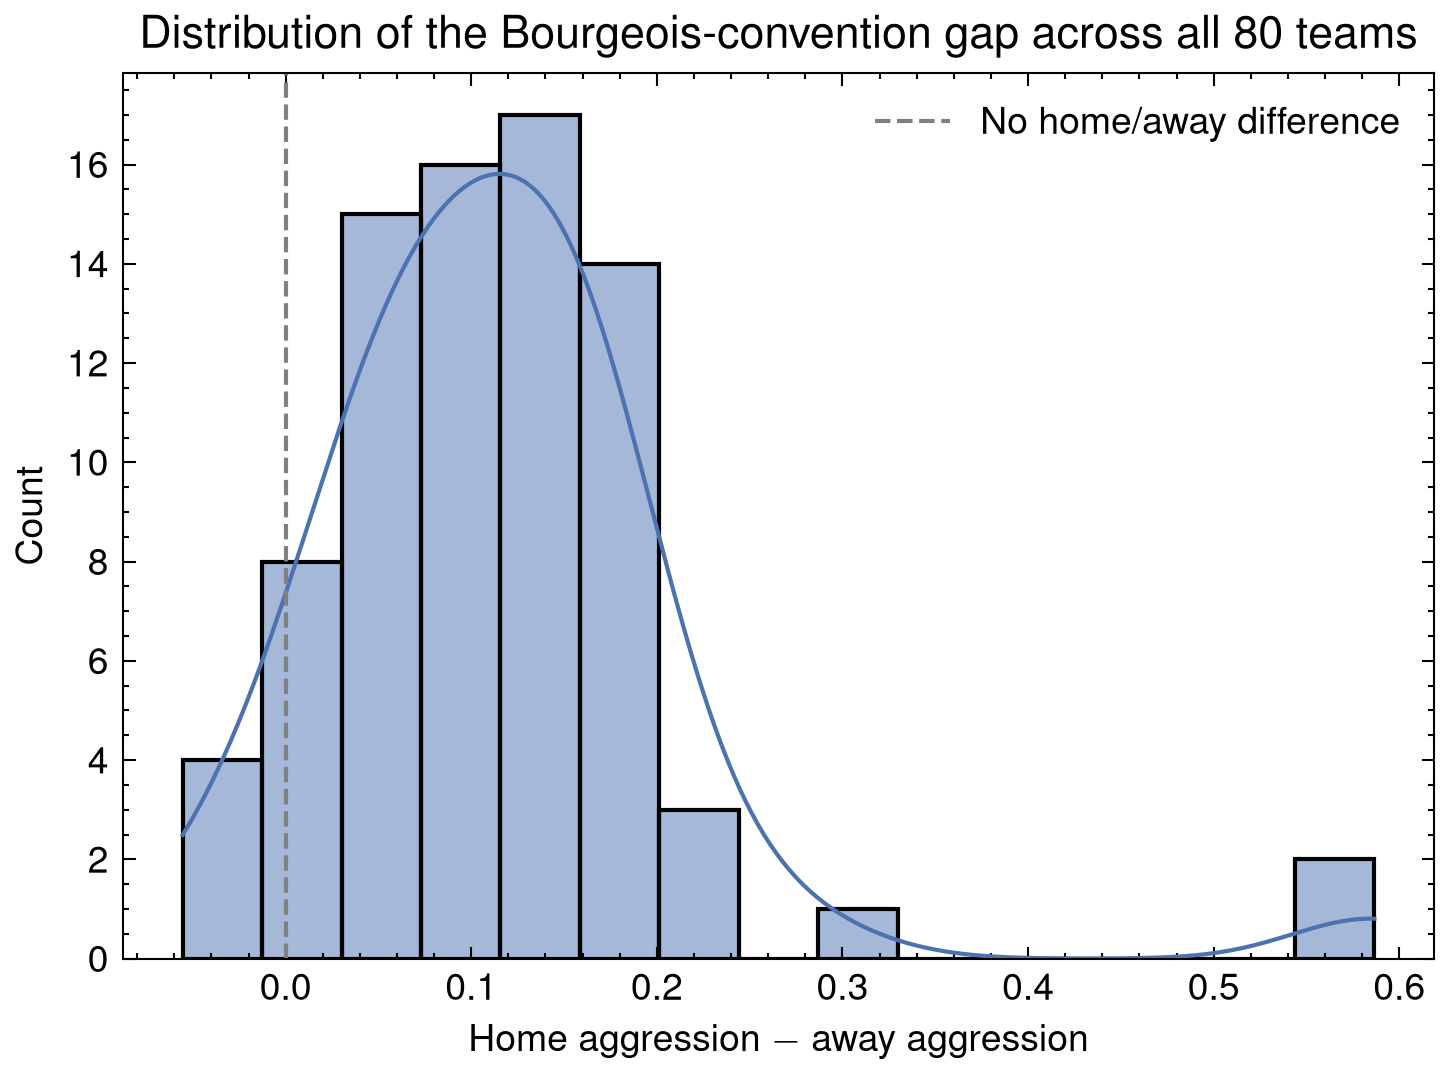

In [51]:
sns.histplot(home_away_diff, kde=True, bins=15, color="#4C72B0")
plt.axvline(0, color="grey", linestyle="--", label="No home/away difference")
plt.xlabel("Home aggression − away aggression")
plt.title("Distribution of the Bourgeois-convention gap across all 80 teams")
plt.legend()
plt.tight_layout()
plt.show()

**Strong evidence for a population-wide Bourgeois convention.** The average `home_minus_away` gap is 0.117, and 75 of 80 teams (93.8%) show it in the Bourgeois direction — both tests are decisively significant (p < 0.0001). For scale, this effect is about 2.8x larger than the first-half-vs-second-half effect tested earlier (0.117 vs. 0.042), which makes home/away status a considerably stronger driver of this score than match state turned out to be.

The mixture-model result needs a careful read, though, and it does **not** show what a naive reading would suggest. BIC decisively prefers 2 components over 1, which sounds like evidence of two genuine strategy types — but both cluster means are *positive* (0.105 and 0.585): there's no cluster centered near zero or negative that would represent a real Antibourgeois-like sub-population. Checking which teams make up the small, high-mean cluster (2% weight, ~2 teams) shows it's just Olympique de Marseille (0.587) and Stade Malherbe Caen (0.583) — two statistical outliers with unusually large home/away swings, not a qualitatively different strategy. The handful of teams with slightly *negative* `home_minus_away` (Rayo Vallecano, Stade de Reims, Bournemouth, Bordeaux, Atalanta) are small in magnitude and get absorbed into the main cluster's spread rather than forming their own — there's no detectable Antibourgeois population here, just noise around a single dominant convention.

**Answering the two framing questions from earlier**: this is a clean answer to the first question — yes, a Bourgeois-like convention is common, strongly and consistently so, across nearly the entire population of 80 teams, and this was shown while keeping the score fully continuous, with no team ever hard-labeled. It does not answer the second question (whether Bourgeois is a true ESS in the formal sense, which needs the V/C payoff reconstruction) — that remains a substantially larger undertaking, left for later.

## Per-league comparison of the Bourgeois-direction effect

The population-level test above pooled all 80 teams together. Breaking it out per league (same test, same team-season `home − away` values, just grouped) gives a league comparison without the matchup-composition confound that a match-level analysis would introduce — a team's own season average doesn't depend on which specific opponents it happened to face. With only 20 teams per league instead of 80 pooled, statistical power is lower, so a league failing to reach significance individually isn't strong evidence against an effect being present there — just a smaller, noisier sample.

In [52]:
home_away_by_league = (
    europe_df.groupby(["league", "team", "venue"])["raw_aggression_index"].mean()
    .unstack("venue")
    .assign(diff=lambda d: d["Home"] - d["Away"])
    .reset_index()
)

league_test_rows = []
for league, group in home_away_by_league.groupby("league"):
    diffs = group["diff"]
    t_stat, t_pvalue = stats.ttest_1samp(diffs, 0)
    league_test_rows.append({
        "league": league,
        "n_teams": len(diffs),
        "mean_diff": diffs.mean(),
        "share_home_gt_away": (diffs > 0).mean(),
        "t_stat": t_stat,
        "p_value": t_pvalue,
    })

league_tests_df = pd.DataFrame(league_test_rows).sort_values("mean_diff", ascending=False)
league_tests_df

,league,n_teams,mean_diff,share_home_gt_away,t_stat,p_value
1,Ligue 1,20,0.171014,0.90,4.915355,9.606943e-05
0,La Liga,20,0.101817,0.95,5.443631,2.980457e-05
3,Serie A,20,0.099017,0.95,7.281542,6.584412e-07
2,Premier League,20,0.095701,0.95,6.726665,1.986778e-06


**All four leagues individually reach significance** (p < 0.001 in every case), despite the much smaller n=20-per-league sample — the effect is strong enough everywhere that the power concern didn't materialize.

**Ligue 1 shows the largest average effect** (mean diff = 0.171), noticeably above the other three, which all cluster tightly together (La Liga 0.102, Serie A 0.099, Premier League 0.096). But Ligue 1 actually has the *lowest* share of teams individually showing home > away (90%, vs. 95% for the other three) — so its larger mean isn't from a broader effect across more teams, it's pulled up by a couple of teams with an unusually large gap. This lines up exactly with the earlier finding from the pooled 80-team mixture model: the two outlier teams identified there (Olympique de Marseille at 0.587, Stade Malherbe Caen at 0.583) are both Ligue 1 clubs. So "Ligue 1 has the strongest Bourgeois-direction effect" is true of the average, but it's a mean inflated by two extreme teams rather than a uniformly stronger tendency across the whole league — worth stating with that caveat rather than as a clean league-wide claim.

The other three leagues are close enough to each other (0.096–0.102) that there's no meaningful practical difference between them — the Bourgeois-direction effect looks like a fairly universal, similarly-sized phenomenon in La Liga, Serie A, and the Premier League, with Ligue 1 as the outlier case, and even that driven by identifiable individual teams rather than a genuinely different league-wide tendency.

## La Liga: classifying teams into the four quadrants

Same idea, back at the team-season level this time, using the La Liga home/away plot's underlying stats: each team's `(mean_home, mean_away)` position relative to La Liga's own medians, with a buffer band (matching the match-level version) catching teams too close to the crosshairs to call.

In [53]:
def classify_teams(stats):
    median_home, median_away = stats["mean_home"].median(), stats["mean_away"].median()
    buffer_home = 0.15 * stats["mean_home"].std()
    buffer_away = 0.15 * stats["mean_away"].std()

    def classify(row):
        home_high = row["mean_home"] > median_home + buffer_home
        home_low = row["mean_home"] < median_home - buffer_home
        away_high = row["mean_away"] > median_away + buffer_away
        away_low = row["mean_away"] < median_away - buffer_away
        if home_high and away_high:
            return "Hawk"
        if home_low and away_low:
            return "Dove"
        if home_high and away_low:
            return "Bourgeois"
        if home_low and away_high:
            return "Antibourgeois"
        return "Uncategorizable"

    result = stats.copy()
    result["strategy"] = result.apply(classify, axis=1)
    return result


la_liga_team_strategies = classify_teams(la_liga_home_away_stats)
la_liga_team_strategies[["team", "mean_home", "mean_away", "strategy"]].sort_values("strategy")

,team,mean_home,mean_away,strategy
12,Rayo Vallecano,0.785404,0.840900,Antibourgeois
10,Málaga,0.795546,0.783550,Antibourgeois
3,Celta Vigo,0.892248,0.731096,Bourgeois
13,Real Betis,0.874167,0.584430,Bourgeois
5,Espanyol,0.881467,0.703650,Bourgeois
9,Levante UD,0.771842,0.739879,Dove
16,Sevilla,0.824432,0.668030,Dove
14,Real Madrid,0.758010,0.741825,Dove
19,Villarreal,0.821733,0.731917,Dove
8,Las Palmas,0.792965,0.690404,Dove


Five teams land in each of Hawk, Dove, and Uncategorizable; three in Bourgeois; two in Antibourgeois — so La Liga's team-level picture is *not* dominated by Bourgeois the way its match-level picture is, which is worth sitting with rather than glossing over.

The standout result: **Barcelona classifies as Hawk, not Bourgeois.** Despite all the earlier investigation into Barcelona's home/away gap, its *absolute* aggression level is high enough in both venues (0.95 home, 0.87 away — both well above the league medians) that it lands in the "aggressive everywhere" corner rather than the "aggressive only at home" one. The home-away *difference* that drove the whole earlier investigation is real, but it's not what determines this quadrant — overall level is. Eibar, Atlético Madrid, Athletic Club, and Real Sociedad join Barcelona in Hawk, which fits their reputations reasonably well.

**Real Madrid lands in Dove** — low aggression in both venues — which is consistent with where they sat in the earlier La Liga ranking table (2nd-lowest forward press rate in the league) despite being a historically elite club, reinforcing the project's central point that this score tracks style, not quality.